In [2]:
import sys, os, duckdb
import pandas as pd
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from config.config import V2_DB

con = duckdb.connect(V2_DB)

# ================================================================
# VARIABLES CLIMÁTICAS CON 100% NULL (ya identificadas)
# ================================================================
VARS_DESCARTADAS = (
    'CLOUD_BT', 'CLOUD_BT_MAX', 'CLOUD_BT_MIN',
    'CLOUD_TT', 'CLOUD_TT_MAX', 'CLOUD_TT_MIN',
    'GWM_HEIGHT', 'GWM_HEIGHT_ANOMALY',
    'IMERG_PRECLIQUID_PROB', 'IMERG_PRECTOT', 'IMERG_PRECTOT_COUNT',
    'LWLAND', 'ORIGINAL_ALLSKY_SFC_LW_DWN', 'ORIGINAL_ALLSKY_SFC_SW_DWN',
    'ORIGINAL_CLRSKY_SFC_LW_DWN', 'ORIGINAL_CLRSKY_SFC_SW_DWN',
    'PRMC', 'PRMC_PRCNTL', 'RZMC', 'RZMC_PRCNTL',
    'SFMC', 'SWLAND', 'SZA'
)
vars_excluidas_sql = ", ".join([f"'{v}'" for v in VARS_DESCARTADAS])

# ================================================================
# PASO 1 — Pivotear climatología y construir dataset
# ================================================================
print("=== CONSTRUCCIÓN DEL DATASET ===\n")
print("1. Obteniendo variables climáticas disponibles...")

vars_clima = con.execute(f"""
    SELECT DISTINCT id_variable
    FROM working.climatologia
    WHERE id_variable NOT IN ({vars_excluidas_sql})
    ORDER BY id_variable
""").df()['id_variable'].tolist()

print(f"   Variables climáticas: {len(vars_clima)}")

pivot_cols = ",\n    ".join([
    f"AVG(CASE WHEN id_variable = '{v}' THEN resultado_numerico END) AS \"{v}\""
    for v in vars_clima
])

print("\n2. Construyendo dataset (JOIN + pivoteo)...")

df = con.execute(f"""
    WITH clima_pivot AS (
        SELECT
            id_clave_inc,
            {pivot_cols}
        FROM working.climatologia
        WHERE id_variable NOT IN ({vars_excluidas_sql})
        GROUP BY id_clave_inc
    ),
    demo_total AS (
        SELECT
            id_cvegeo,
            anio,
            SUM(pob_total) AS pob_total
        FROM working.demografia
        GROUP BY id_cvegeo, anio
    )
    SELECT
        -- IDENTIFICADOR
        i.id_clave_inc,

        -- FEATURES DISPONIBLES AL MOMENTO DE DETECCIÓN
        i.latitud,
        i.longitud,
        i.anio,
        EXTRACT(MONTH FROM i.fecha_inicio)::INTEGER AS mes,
        EXTRACT(DOW   FROM i.fecha_inicio)::INTEGER AS dia_semana,
        i.tipo_de_incendio,
        v.tipo_de_vegetacion,
        v.regimen_del_fuego,
        m.nombre_municipio,
        o.hora_deteccion,
        dem.pob_total,

        -- TARGET
        d.tamanio,

        -- CLIMA (promedio 10 días previos — incluye NDWI y NDMI)
        cp.*

    FROM working.incendios i
    LEFT JOIN working.vegetacion   v   ON i.id_vegetacion = v.id_vegetacion
    LEFT JOIN working.municipios   m   ON i.id_cvegeo     = m.id_cvegeo
    LEFT JOIN working.operaciones  o   ON i.id_clave_inc  = o.id_clave_inc
    LEFT JOIN working.danos        d   ON i.id_clave_inc  = d.id_clave_inc
    LEFT JOIN demo_total           dem ON i.id_cvegeo     = dem.id_cvegeo
                                      AND i.anio          = dem.anio
    LEFT JOIN clima_pivot          cp  ON i.id_clave_inc  = cp.id_clave_inc
""").df()

con.close()

df = df.loc[:, ~df.columns.duplicated()]

# ================================================================
# PASO 2 — Colapsar clases del target
# ================================================================
print("\n3. Procesando target...")

mapa_tamanio = {
    '0 a 5 hectareas'       : '1_0_a_5',
    '6 a 10 hectareas'      : '2_6_a_20',
    '11 a 20 hectareas'     : '2_6_a_20',
    '21 a 50 hectareas'     : '3_21_a_50',
    '51 a 100 hectareas'    : '4_mas_de_50',
    'mayor a 100 hectareas' : '4_mas_de_50',
}

df['tamanio_modelo'] = df['tamanio'].map(mapa_tamanio)

sin_mapear = df['tamanio_modelo'].isnull().sum()
if sin_mapear > 0:
    print(f"   ADVERTENCIA: {sin_mapear} valores no mapeados:")
    print(df[df['tamanio_modelo'].isnull()]['tamanio'].value_counts())

# ================================================================
# PASO 3 — hora_deteccion a minutos desde medianoche
# ================================================================
df['hora_deteccion'] = pd.to_datetime(
    df['hora_deteccion'].astype(str), errors='coerce'
)
df['hora_deteccion_min'] = (
    df['hora_deteccion'].dt.hour * 60 +
    df['hora_deteccion'].dt.minute
)
df = df.drop(columns=['hora_deteccion'])

# ================================================================
# INSPECCIÓN FINAL
# ================================================================
print("\n=== INSPECCIÓN DEL DATASET ===")
print(f"\nShape          : {df.shape}")

print(f"\nTarget (tamanio_modelo):")
dist = df['tamanio_modelo'].value_counts().sort_index()
total = len(df)
for clase, cnt in dist.items():
    print(f"   {clase:<20} {cnt:>5}  ({cnt/total*100:.1f}%)")

print(f"\nNULLs por columna (solo las que tienen):")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(nulos.to_string())

print(f"\nColumnas categóricas:")
for col in df.select_dtypes(include='object').columns:
    print(f"   {col:<25} {df[col].nunique():>4} valores únicos")

print("\n=== DATASET LISTO ===")

# ================================================================
# LIMPIEZA FINAL DEL DATASET
# ================================================================

# Quitar columnas sobrantes
df = df.drop(columns=['id_clave_inc_1', 'tamanio'], errors='ignore')

# Confirmar que quedó limpio
print("\n=== DATASET FINAL LIMPIO ===")
print(f"Shape          : {df.shape}")
print(f"Columnas sobrantes: { [c for c in ['id_clave_inc_1','tamanio'] if c in df.columns] or 'Ninguna' }")

# Separar features del target e identificador
ID_COL     = 'id_clave_inc'
TARGET_COL = 'tamanio_modelo'

cols_features = [c for c in df.columns if c not in [ID_COL, TARGET_COL]]
cols_clima    = [c for c in cols_features if c in vars_clima]
cols_no_clima = [c for c in cols_features if c not in vars_clima]

print(f"\nFeatures totales    : {len(cols_features)}")
print(f"  - Climáticas      : {len(cols_clima)}")
print(f"  - No climáticas   : {len(cols_no_clima)}")
print(f"\nNo climáticas       : {cols_no_clima}")
print(f"\nListo para descarte de variables.")

=== CONSTRUCCIÓN DEL DATASET ===

1. Obteniendo variables climáticas disponibles...
   Variables climáticas: 122

2. Construyendo dataset (JOIN + pivoteo)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


3. Procesando target...

=== INSPECCIÓN DEL DATASET ===

Shape          : (12703, 137)

Target (tamanio_modelo):
   1_0_a_5               9646  (75.9%)
   2_6_a_20              2043  (16.1%)
   3_21_a_50              551  (4.3%)
   4_mas_de_50            463  (3.6%)

NULLs por columna (solo las que tienen):
latitud               174
longitud              174
EVLAND                105
TSOIL5                105
EVPTRNS               105
FRSNO                 105
GWETPROF              105
GWETROOT              105
PRECSNOLAND           105
SNODP                 105
TSOIL1                105
TSURF                 105
TSOIL2                105
TSOIL3                105
TSOIL4                105
TSOIL6                105
CLRSKY_NKT             33
hora_deteccion_min      3
NDMI                    2

Columnas categóricas:
   id_clave_inc              12703 valores únicos
   tipo_de_incendio             4 valores únicos
   tipo_de_vegetacion          23 valores únicos
   regimen_del_fuego     

/tmp/ipykernel_41277/3770539767.py:127: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hora_deteccion'] = pd.to_datetime(


In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ================================================================
# PASO 1 — CLUSTERING DE CORRELACIÓN (solo climáticas)
# ================================================================
print("\n=== DESCARTE — PASO 1: CLUSTERING DE CORRELACIÓN ===\n")

# Encoding ordinal del target
orden_clases = [['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50']]
enc_target   = OrdinalEncoder(categories=orden_clases)
y_ord        = enc_target.fit_transform(df[[TARGET_COL]]).ravel()

# Preparar matriz climática
df_clima = df[cols_clima].copy()

# --- CORRECCIÓN DE MATRIZ PARA EVITAR ValueError ---
# 1. Eliminar columnas que son 100% nulas
df_clima = df_clima.dropna(axis=1, how='all')

# 2. Imputar nulos restantes con la mediana
df_clima = df_clima.fillna(df_clima.median())

# 3. Eliminar columnas constantes (Varianza = 0) que causan división por cero en correlación
desviacion = df_clima.std()
cols_validas = desviacion[desviacion > 0].index

if len(cols_validas) < len(df_clima.columns):
    eliminadas = len(df_clima.columns) - len(cols_validas)
    print(f"-> Precaución: Se descartaron {eliminadas} variablesP climáticas por ser constantes (varianza cero).")
    df_clima = df_clima[cols_validas]
# ---------------------------------------------------

# Distancia directamente desde pdist sobre la transpuesta
# Cada variable es un punto en R^n_incendios
dist_condensada = pdist(df_clima.values.T, metric='correlation')

# 4. Asegurar matriz finita (reemplaza cualquier NaN residual o infinito)
dist_condensada = np.nan_to_num(dist_condensada, nan=0.0, posinf=1.0, neginf=-1.0)
dist_condensada = np.clip(dist_condensada, 0, None)  # eliminar negativos por float

# Clustering jerárquico
linkage        = hierarchy.ward(dist_condensada)
cluster_labels = hierarchy.fcluster(linkage, t=0.5, criterion='distance')

grupos_df = pd.DataFrame({
    'variable': df_clima.columns,
    'grupo'   : cluster_labels
})

# Representante = el que más correlaciona con el target
representantes = []
log_grupos     = []

for g in sorted(grupos_df['grupo'].unique()):
    vars_grupo  = grupos_df[grupos_df['grupo'] == g]['variable'].tolist()
    
    # Manejar posibles warnings al calcular correlación con el target
    corr_target = {}
    for v in vars_grupo:
        try:
            corr_val = abs(np.corrcoef(df_clima[v], y_ord)[0, 1])
            # Si el cálculo da NaN, se le asigna 0 de correlación
            corr_target[v] = corr_val if not np.isnan(corr_val) else 0.0
        except:
            corr_target[v] = 0.0

    mejor = max(corr_target, key=corr_target.get)
    representantes.append(mejor)
    log_grupos.append({
        'grupo'        : g,
        'n_vars'       : len(vars_grupo),
        'representante': mejor,
        'corr_target'  : round(corr_target[mejor], 4),
        'descartadas'  : ', '.join([v for v in vars_grupo if v != mejor])
    })

df_log = (pd.DataFrame(log_grupos)
            .sort_values('corr_target', ascending=False)
            .reset_index(drop=True))

print(f"Climáticas procesadas  : {len(df_clima.columns)}")
print(f"Grupos encontrados     : {len(representantes)}")
print(f"Variables eliminadas   : {len(df_clima.columns) - len(representantes)}")
print(f"\nTodos los grupos (ordenados por correlación con target):")
print(df_log[['representante', 'n_vars', 'corr_target', 'descartadas']].to_string(index=False))

cols_clima_reducidas = representantes.copy()
print(f"\nRepresentantes seleccionados ({len(cols_clima_reducidas)}):")
print(cols_clima_reducidas)

# ================================================================
# GRÁFICAS
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Clustering de correlación — variables climáticas', fontsize=14)

# --- Gráfica 1: Dendrograma ---
ax1 = axes[0]
hierarchy.dendrogram(
    linkage,
    ax=ax1,
    no_labels=True,
    color_threshold=0.15,
    above_threshold_color='#888780'
)
ax1.axhline(y=0.15, color='#E24B4A', linestyle='--', linewidth=1, label='Umbral t=0.5')
ax1.set_title('Dendrograma de agrupación')
ax1.set_xlabel('Variables climáticas')
ax1.set_ylabel('Distancia')
ax1.legend(fontsize=9)

ax2 = axes[1]
tamanos = df_log['n_vars'].value_counts().sort_index()
ax2.bar(tamanos.index.astype(str), tamanos.values, color='#378ADD', width=0.6)
ax2.set_title('Distribución del tamaño de grupos')
ax2.set_xlabel('Variables por grupo')
ax2.set_ylabel('Número de grupos')
for i, (x, v) in enumerate(zip(tamanos.index, tamanos.values)):
    ax2.text(i, v + 0.1, str(v), ha='center', fontsize=9)

# --- Gráfica 3: Top 20 representantes por correlación con target ---
ax3 = axes[2]
top20   = df_log.head(20)
colores = [
    '#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
    for v in top20['corr_target']
]
ax3.barh(
    top20['representante'][::-1],
    top20['corr_target'][::-1],
    color=colores[::-1],
    height=0.6
)
ax3.set_title('Top 20 representantes\n(correlación con tamanio)')
ax3.set_xlabel('Correlación absoluta con target')
ax3.axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1, label='Corr > 0.05')
ax3.axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1, label='Corr > 0.02')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('clustering_correlacion.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nGráfica guardada: clustering_correlacion.png")


=== DESCARTE — PASO 1: CLUSTERING DE CORRELACIÓN ===

-> Precaución: Se descartaron 3 variables climáticas por ser constantes (varianza cero).
Climáticas procesadas  : 119
Grupos encontrados     : 33
Variables eliminadas   : 86

Todos los grupos (ordenados por correlación con target):
     representante  n_vars  corr_target                                                                                                                                                              descartadas
          T10M_MAX      17       0.2176                                                  CDD0, CDD18_3, T10M, T10M_MIN, T2M, T2MWET, T2M_MAX, T2M_MIN, TS, TSOIL1, TSOIL2, TSOIL3, TSOIL4, TSURF, TS_MAX, TS_MIN
            TSOIL5       5       0.2084                                                                                                                                                 PBLTOP, PS, RHOA, TSOIL6
              RH2M       2       0.1772                                               

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================================================================
# CONFIGURACIÓN
# ================================================================
TARGET_COL  = 'tamanio_modelo'
ID_COL      = 'id_clave_inc'
ANIO_CORTE  = 2023   # train: < 2023 / test: >= 2023

# Features finales: 33 climáticas + 11 no climáticas
FEATURES = cols_clima_reducidas + [
    'latitud', 'longitud', 'anio', 'mes', 'dia_semana',
    'tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego',
    'nombre_municipio', 'pob_total', 'hora_deteccion_min'
]

# ================================================================
# PASO 1 — Preparar X e y
# ================================================================
print("=== ENTRENAMIENTO RANDOM FOREST ===\n")

df_model = df[FEATURES + [TARGET_COL, 'anio']].copy()
# Diagnóstico de duplicados
print("Columnas duplicadas en df_model:")
print(df_model.columns[df_model.columns.duplicated()].tolist())

# Diagnóstico de duplicados en FEATURES
from collections import Counter
duplicados_features = [k for k, v in Counter(FEATURES).items() if v > 1]
print(f"Duplicados en lista FEATURES: {duplicados_features}")

# Fix — eliminar columnas duplicadas
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

# Fix — eliminar duplicados de la lista FEATURES
FEATURES = list(dict.fromkeys(FEATURES))
print(f"Features tras deduplicar: {len(FEATURES)}")

# Imputación por municipio para modelo final
cols_con_nulos = [c for c in FEATURES if df_model[c].isnull().values.sum() > 0]
for col in cols_con_nulos:
    if col in ['latitud', 'longitud']:
        # Coordenadas: imputar con mediana del municipio
        mediana_mun = df_model.groupby('nombre_municipio')[col].transform('median')
        df_model[col] = df_model[col].fillna(mediana_mun).fillna(df_model[col].median())
    else:
        # Climáticas: imputar con mediana del municipio → global
        mediana_mun = df_model.groupby('nombre_municipio')[col].transform('median')
        df_model[col] = df_model[col].fillna(mediana_mun).fillna(df_model[col].median())

print(f"NULLs restantes: {df_model[FEATURES].isnull().sum().sum()}")

# Encoding ordinal del target
orden_clases = [['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50']]
enc_target   = OrdinalEncoder(categories=orden_clases)
df_model['y'] = enc_target.fit_transform(df_model[[TARGET_COL]]).ravel().astype(int)

# Encoding de categóricas
cats = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio']
encoders = {}
for col in cats:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].fillna('desconocido'))
    encoders[col] = le

# ================================================================
# PASO 2 — Split temporal train/test
# ================================================================
train = df_model[df_model['anio'] <  ANIO_CORTE]
test  = df_model[df_model['anio'] >= ANIO_CORTE]

X_train = train[FEATURES]
y_train = train['y']
X_test  = test[FEATURES]
y_test  = test['y']

print(f"Train: {len(train):,} registros ({train['anio'].min()}–{train['anio'].max()})")
print(f"Test : {len(test):,}  registros ({test['anio'].min()}–{test['anio'].max()})")
print(f"\nDistribución train:")
for i, clase in enumerate(orden_clases[0]):
    n = (y_train == i).sum()
    print(f"  {clase:<20} {n:>5} ({n/len(y_train)*100:.1f}%)")
print(f"\nDistribución test:")
for i, clase in enumerate(orden_clases[0]):
    n = (y_test == i).sum()
    print(f"  {clase:<20} {n:>5} ({n/len(y_test)*100:.1f}%)")

# ================================================================
# PASO 3 — Pesos por clase (compensar desbalance)
# ================================================================
pesos = compute_class_weight(class_weight='balanced',
                              classes=np.unique(y_train), y=y_train)
pesos_dict = dict(zip(np.unique(y_train), pesos))
print(f"\nPesos por clase: { {k: round(v,2) for k,v in pesos_dict.items()} }")

# ================================================================
# PASO 4 — Entrenar Random Forest
# ================================================================
print("\nEntrenando Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight=pesos_dict,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print("Entrenamiento completado.")

# ================================================================
# PASO 5 — Evaluación
# ================================================================
y_pred = rf.predict(X_test)

print("\n=== MÉTRICAS ===\n")
print(f"MAE ordinal : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  (0 = perfecto, 1 = error de 1 clase, 3 = error máximo)\n")

nombres_clases = ['0_a_5', '6_a_20', '21_a_50', 'mas_de_50']
print(classification_report(y_test, y_pred, target_names=nombres_clases))

# ================================================================
# PASO 6 — Gráficas
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest — Predicción de severidad de incendios', fontsize=13)

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión (test 2023–2025)')
axes[0].tick_params(axis='x', rotation=20)

# --- Feature importance top 20 ---
imp_df = pd.DataFrame({
    'variable'   : FEATURES,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False).head(20)

colores = ['#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
           for v in imp_df['importancia']]
axes[1].barh(imp_df['variable'][::-1], imp_df['importancia'][::-1],
             color=colores[::-1], height=0.6)
axes[1].set_title('Top 20 variables más importantes')
axes[1].set_xlabel('Feature importance (Gini)')
axes[1].axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1)
axes[1].axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('rf_resultado.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nGráfica guardada: rf_resultado.png")

# ================================================================
# RESUMEN FINAL
# ================================================================
print("\n=== RESUMEN ===")
print(f"Features usadas    : {len(FEATURES)}")
print(f"Top 5 más importantes:")
print(imp_df.head(5)[['variable','importancia']].to_string(index=False))

=== ENTRENAMIENTO RANDOM FOREST ===

Columnas duplicadas en df_model:
['anio']
Duplicados en lista FEATURES: []
Features tras deduplicar: 44
NULLs restantes: 0
Train: 9,901 registros (2015–2022)
Test : 2,802  registros (2023–2025)

Distribución train:
  1_0_a_5               8004 (80.8%)
  2_6_a_20              1400 (14.1%)
  3_21_a_50              299 (3.0%)
  4_mas_de_50            198 (2.0%)

Distribución test:
  1_0_a_5               1642 (58.6%)
  2_6_a_20               643 (22.9%)
  3_21_a_50              252 (9.0%)
  4_mas_de_50            265 (9.5%)

Pesos por clase: {np.int64(0): np.float64(0.31), np.int64(1): np.float64(1.77), np.int64(2): np.float64(8.28), np.int64(3): np.float64(12.5)}

Entrenando Random Forest...
Entrenamiento completado.

=== MÉTRICAS ===

MAE ordinal : 0.6499
  (0 = perfecto, 1 = error de 1 clase, 3 = error máximo)

              precision    recall  f1-score   support

       0_a_5       0.62      0.94      0.75      1642
      6_a_20       0.30      0.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================================================================
# CONFIGURACIÓN
# ================================================================
TARGET_COL  = 'tamanio_modelo'
ID_COL      = 'id_clave_inc'
ANIO_CORTE  = 2023

FEATURES = cols_clima_reducidas + [
    'latitud', 'longitud', 'anio', 'mes', 'dia_semana',
    'tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego',
    'nombre_municipio', 'pob_total', 'hora_deteccion_min'
]

# ================================================================
# PASO 1 — Preparar X e y
# ================================================================
print("=== ENTRENAMIENTO RANDOM FOREST (v2) ===\n")

df_model = df[FEATURES + [TARGET_COL, 'anio']].copy()

# Eliminar columnas duplicadas
df_model = df_model.loc[:, ~df_model.columns.duplicated()]
FEATURES  = list(dict.fromkeys(FEATURES))

# Imputación por municipio → global como fallback
cols_con_nulos = [c for c in FEATURES if df_model[c].isnull().values.sum() > 0]
for col in cols_con_nulos:
    mediana_mun = df_model.groupby('nombre_municipio')[col].transform('median')
    df_model[col] = df_model[col].fillna(mediana_mun).fillna(df_model[col].median())

print(f"NULLs restantes : {df_model[FEATURES].isnull().values.sum()}")
print(f"Features totales: {len(FEATURES)}")

# Encoding ordinal del target
orden_clases = [['1_0_a_5', '2_6_a_20', '3_21_a_50', '4_mas_de_50']]
enc_target   = OrdinalEncoder(categories=orden_clases)
df_model['y'] = enc_target.fit_transform(df_model[[TARGET_COL]]).ravel().astype(int)

# Encoding de categóricas
cats = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio']
encoders = {}
for col in cats:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].fillna('desconocido'))
    encoders[col] = le

# ================================================================
# PASO 2 — Split temporal
# ================================================================
train = df_model[df_model['anio'] <  ANIO_CORTE]
test  = df_model[df_model['anio'] >= ANIO_CORTE]

X_train = train[FEATURES]
y_train = train['y']
X_test  = test[FEATURES]
y_test  = test['y']

print(f"\nTrain: {len(train):,} registros ({train['anio'].min()}–{train['anio'].max()})")
print(f"Test : {len(test):,}  registros ({test['anio'].min()}–{test['anio'].max()})")

print(f"\nDistribución train:")
for i, clase in enumerate(orden_clases[0]):
    n = (y_train == i).sum()
    print(f"  {clase:<20} {n:>5} ({n/len(y_train)*100:.1f}%)")

print(f"\nDistribución test:")
for i, clase in enumerate(orden_clases[0]):
    n = (y_test == i).sum()
    print(f"  {clase:<20} {n:>5} ({n/len(y_test)*100:.1f}%)")

# ================================================================
# PASO 3 — Pesos manuales (más agresivos para clases críticas)
# ================================================================
pesos_dict = {
    0:  0.3,   # 0_a_5      — clase dominante, penalizar menos
    1:  2.0,   # 6_a_20
    2: 15.0,   # 21_a_50    — clase crítica
    3: 20.0    # mas_de_50  — clase más crítica
}
print(f"\nPesos manuales: {pesos_dict}")

# ================================================================
# PASO 4 — Entrenar Random Forest (v2)
# ================================================================
print("\nEntrenando Random Forest v2...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,          # limitado para evitar memorizar 0_a_5
    min_samples_leaf=3,    # más flexible para clases minoritarias
    max_features='sqrt',
    class_weight=pesos_dict,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print("Entrenamiento completado.")

# ================================================================
# PASO 5 — Evaluación
# ================================================================
y_pred = rf.predict(X_test)

print("\n=== MÉTRICAS ===\n")
print(f"MAE ordinal : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  (0 = perfecto, 1 = error de 1 clase, 3 = error máximo)\n")

nombres_clases = ['0_a_5', '6_a_20', '21_a_50', 'mas_de_50']
print(classification_report(y_test, y_pred, target_names=nombres_clases))

# ================================================================
# PASO 6 — Gráficas
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest v2 — Predicción de severidad de incendios', fontsize=13)

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión (test 2023–2025)')
axes[0].tick_params(axis='x', rotation=20)

# --- Feature importance top 20 ---
imp_df = pd.DataFrame({
    'variable'   : FEATURES,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False).head(20)

colores = ['#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
           for v in imp_df['importancia']]
axes[1].barh(imp_df['variable'][::-1], imp_df['importancia'][::-1],
             color=colores[::-1], height=0.6)
axes[1].set_title('Top 20 variables más importantes')
axes[1].set_xlabel('Feature importance (Gini)')
axes[1].axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1, label='Corr > 0.05')
axes[1].axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1, label='Corr > 0.02')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('rf_v2_resultado.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nGráfica guardada: rf_v2_resultado.png")

# ================================================================
# RESUMEN — comparativa v1 vs v2
# ================================================================
print("\n=== RESUMEN v2 ===")
print(f"Features usadas : {len(FEATURES)}")
print(f"\nTop 10 más importantes:")
print(imp_df.head(10)[['variable', 'importancia']].to_string(index=False))

print("\n=== COMPARATIVA RECALL (lo más importante) ===")
from sklearn.metrics import recall_score
recall_por_clase = recall_score(y_test, y_pred, average=None)
for i, (clase, rec) in enumerate(zip(nombres_clases, recall_por_clase)):
    emoji = "✅" if rec > 0.40 else "⚠️" if rec > 0.20 else "❌"
    print(f"  {emoji} {clase:<12} recall: {rec:.3f}")

=== ENTRENAMIENTO RANDOM FOREST (v2) ===

NULLs restantes : 0
Features totales: 44

Train: 9,901 registros (2015–2022)
Test : 2,802  registros (2023–2025)

Distribución train:
  1_0_a_5               8004 (80.8%)
  2_6_a_20              1400 (14.1%)
  3_21_a_50              299 (3.0%)
  4_mas_de_50            198 (2.0%)

Distribución test:
  1_0_a_5               1642 (58.6%)
  2_6_a_20               643 (22.9%)
  3_21_a_50              252 (9.0%)
  4_mas_de_50            265 (9.5%)

Pesos manuales: {0: 0.3, 1: 2.0, 2: 15.0, 3: 20.0}

Entrenando Random Forest v2...
Entrenamiento completado.

=== MÉTRICAS ===

MAE ordinal : 0.6695
  (0 = perfecto, 1 = error de 1 clase, 3 = error máximo)

              precision    recall  f1-score   support

       0_a_5       0.60      0.97      0.74      1642
      6_a_20       0.32      0.07      0.11       643
     21_a_50       0.00      0.00      0.00       252
   mas_de_50       0.40      0.05      0.08       265

    accuracy                    

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================================================================
# CONFIGURACIÓN
# ================================================================
TARGET_COL = 'tamanio_modelo'
ANIO_CORTE = 2023

FEATURES = cols_clima_reducidas + [
    'latitud', 'longitud', 'anio', 'mes', 'dia_semana',
    'tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego',
    'nombre_municipio', 'pob_total', 'hora_deteccion_min'
]

# ================================================================
# PASO 1 — Preparar dataset
# ================================================================
print("=== RANDOM FOREST BINARIO — Controlable vs Severo ===\n")

df_model = df[FEATURES + [TARGET_COL, 'anio']].copy()
df_model  = df_model.loc[:, ~df_model.columns.duplicated()]
FEATURES  = list(dict.fromkeys(FEATURES))

# Imputación por municipio → global como fallback
cols_con_nulos = [c for c in FEATURES if df_model[c].isnull().values.sum() > 0]
for col in cols_con_nulos:
    mediana_mun   = df_model.groupby('nombre_municipio')[col].transform('median')
    df_model[col] = df_model[col].fillna(mediana_mun).fillna(df_model[col].median())

print(f"NULLs restantes : {df_model[FEATURES].isnull().values.sum()}")
print(f"Features totales: {len(FEATURES)}")

# Target binario
# 0 = Controlable  (0_a_5  + 6_a_20)
# 1 = Severo       (21_a_50 + mas_de_50)
mapa_binario = {
    '1_0_a_5'     : 0,
    '2_6_a_20'    : 0,
    '3_21_a_50'   : 1,
    '4_mas_de_50' : 1,
}
df_model['y'] = df_model[TARGET_COL].map(mapa_binario)

print(f"\nDistribución binaria completa:")
dist = df_model['y'].value_counts().sort_index()
for clase, n in dist.items():
    label = 'Controlable' if clase == 0 else 'Severo'
    print(f"  {clase} {label:<12} {n:>5} ({n/len(df_model)*100:.1f}%)")

# Encoding de categóricas
cats = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio']
encoders = {}
for col in cats:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].fillna('desconocido'))
    encoders[col] = le

# ================================================================
# PASO 2 — Split temporal
# ================================================================
train = df_model[df_model['anio'] <  ANIO_CORTE]
test  = df_model[df_model['anio'] >= ANIO_CORTE]

X_train = train[FEATURES]
y_train = train['y']
X_test  = test[FEATURES]
y_test  = test['y']

print(f"\nTrain: {len(train):,} registros ({train['anio'].min()}–{train['anio'].max()})")
print(f"Test : {len(test):,}  registros ({test['anio'].min()}–{test['anio'].max()})")

print(f"\nDistribución train:")
for clase, label in [(0,'Controlable'), (1,'Severo')]:
    n = (y_train == clase).sum()
    print(f"  {clase} {label:<12} {n:>5} ({n/len(y_train)*100:.1f}%)")

print(f"\nDistribución test:")
for clase, label in [(0,'Controlable'), (1,'Severo')]:
    n = (y_test == clase).sum()
    print(f"  {clase} {label:<12} {n:>5} ({n/len(y_test)*100:.1f}%)")

# ================================================================
# PASO 3 — Pesos balanceados automáticos
# ================================================================
pesos = compute_class_weight(class_weight='balanced',
                              classes=np.unique(y_train), y=y_train)
pesos_dict = dict(zip(np.unique(y_train), pesos))
print(f"\nPesos automáticos: { {k: round(v,2) for k,v in pesos_dict.items()} }")

# ================================================================
# PASO 4 — Entrenar RF binario
# ================================================================
print("\nEntrenando Random Forest binario...")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight=pesos_dict,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print("Entrenamiento completado.")

# ================================================================
# PASO 5 — Evaluación con umbral ajustado
# Para sistemas de alerta preferimos más recall en clase Severo
# aunque sacrifiquemos algo de precisión
# ================================================================
y_proba  = rf.predict_proba(X_test)[:, 1]  # probabilidad de Severo

# Umbral estándar 0.50
y_pred_50 = (y_proba >= 0.50).astype(int)

# Umbral reducido 0.35 — más sensible a incendios severos
y_pred_35 = (y_proba >= 0.35).astype(int)

print("\n=== MÉTRICAS CON UMBRAL 0.50 (estándar) ===\n")
print(classification_report(y_test, y_pred_50,
      target_names=['Controlable', 'Severo']))

print("\n=== MÉTRICAS CON UMBRAL 0.35 (más sensible) ===\n")
print(classification_report(y_test, y_pred_35,
      target_names=['Controlable', 'Severo']))

print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"  (1.0 = perfecto, 0.5 = aleatorio)\n")

# ================================================================
# PASO 6 — Gráficas
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Random Forest Binario — Controlable vs Severo', fontsize=13)

# --- Matriz de confusión umbral 0.50 ---
cm_50 = confusion_matrix(y_test, y_pred_50)
ConfusionMatrixDisplay(cm_50, display_labels=['Controlable','Severo']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión\nUmbral 0.50')

# --- Matriz de confusión umbral 0.35 ---
cm_35 = confusion_matrix(y_test, y_pred_35)
ConfusionMatrixDisplay(cm_35, display_labels=['Controlable','Severo']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Matriz de confusión\nUmbral 0.35 (más sensible)')

# --- Feature importance top 20 ---
imp_df = pd.DataFrame({
    'variable'   : FEATURES,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False).head(20)

colores = ['#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
           for v in imp_df['importancia']]
axes[2].barh(imp_df['variable'][::-1], imp_df['importancia'][::-1],
             color=colores[::-1], height=0.6)
axes[2].set_title('Top 20 variables más importantes')
axes[2].set_xlabel('Feature importance (Gini)')
axes[2].axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1, label='>0.05')
axes[2].axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1, label='>0.02')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('rf_binario.png', dpi=150, bbox_inches='tight')
plt.close()
print("Gráfica guardada: rf_binario.png")

# ================================================================
# RESUMEN FINAL
# ================================================================
print("\n=== RESUMEN FINAL ===")
print(f"AUC-ROC          : {roc_auc_score(y_test, y_proba):.4f}")

from sklearn.metrics import recall_score, precision_score
for umbral, y_pred in [(0.50, y_pred_50), (0.35, y_pred_35)]:
    rec  = recall_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    emoji = "✅" if rec > 0.50 else "⚠️" if rec > 0.30 else "❌"
    print(f"\nUmbral {umbral}:")
    print(f"  {emoji} Recall  Severo : {rec:.3f}  (de cada 10 incendios grandes, detecta {rec*10:.1f})")
    print(f"  Precisión Severo : {prec:.3f}  (de cada 10 alertas, {prec*10:.1f} son reales)")

print(f"\nTop 5 variables más importantes:")
print(imp_df.head(5)[['variable','importancia']].to_string(index=False))

=== RANDOM FOREST BINARIO — Controlable vs Severo ===

NULLs restantes : 0
Features totales: 44

Distribución binaria completa:
  0 Controlable  11689 (92.0%)
  1 Severo        1014 (8.0%)

Train: 9,901 registros (2015–2022)
Test : 2,802  registros (2023–2025)

Distribución train:
  0 Controlable   9404 (95.0%)
  1 Severo         497 (5.0%)

Distribución test:
  0 Controlable   2285 (81.5%)
  1 Severo         517 (18.5%)

Pesos automáticos: {np.int64(0): np.float64(0.53), np.int64(1): np.float64(9.96)}

Entrenando Random Forest binario...
Entrenamiento completado.

=== MÉTRICAS CON UMBRAL 0.50 (estándar) ===

              precision    recall  f1-score   support

 Controlable       0.82      1.00      0.90      2285
      Severo       0.71      0.01      0.02       517

    accuracy                           0.82      2802
   macro avg       0.77      0.50      0.46      2802
weighted avg       0.80      0.82      0.74      2802


=== MÉTRICAS CON UMBRAL 0.35 (más sensible) ===

      

In [13]:
# Distribución de severidad por año
print("=== SEVERIDAD POR AÑO ===\n")

severo_anio = df.copy()
severo_anio['es_severo'] = severo_anio['tamanio_modelo'].isin(
    ['3_21_a_50', '4_mas_de_50']
).astype(int)

resumen = severo_anio.groupby('anio').agg(
    total        = ('es_severo', 'count'),
    severos      = ('es_severo', 'sum'),
).assign(pct_severo = lambda x: (x['severos'] / x['total'] * 100).round(1))

print(resumen.to_string())

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolución de incendios severos por año', fontsize=13)

axes[0].bar(resumen.index, resumen['total'], color='#378ADD', alpha=0.7, label='Total')
axes[0].bar(resumen.index, resumen['severos'], color='#E24B4A', label='Severos')
axes[0].set_title('Conteo absoluto por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Incendios')
axes[0].legend()
axes[0].axvline(x=2022.5, color='black', linestyle='--', linewidth=1, label='Corte train/test')

axes[1].plot(resumen.index, resumen['pct_severo'],
             marker='o', color='#E24B4A', linewidth=2)
axes[1].axvline(x=2022.5, color='black', linestyle='--', linewidth=1, label='Corte train/test')
axes[1].axhline(y=resumen['pct_severo'].mean(), color='#BA7517',
                linestyle='--', linewidth=1, label=f"Media: {resumen['pct_severo'].mean():.1f}%")
axes[1].set_title('% Incendios severos por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% Severos')
axes[1].legend()
axes[1].set_ylim(0, resumen['pct_severo'].max() * 1.3)

plt.tight_layout()
plt.savefig('severidad_por_anio.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nGráfica guardada: severidad_por_anio.png")

=== SEVERIDAD POR AÑO ===

      total  severos  pct_severo
anio                            
2015    518        4         0.8
2016   1483       25         1.7
2017   1450       53         3.7
2018   1380       62         4.5
2019   1475       69         4.7
2020   1097       64         5.8
2021   1493      115         7.7
2022   1005      105        10.4
2023    927      126        13.6
2024   1079      238        22.1
2025    796      153        19.2

Gráfica guardada: severidad_por_anio.png


In [14]:
# Correr este diagnóstico primero
for corte in [2021, 2022, 2023]:
    train_tmp = df_model[df_model['anio'] <  corte]
    test_tmp  = df_model[df_model['anio'] >= corte]
    pct_s_train = (train_tmp['y'] == 1).mean() * 100
    pct_s_test  = (test_tmp['y']  == 1).mean() * 100
    print(f"Corte {corte} → Train: {len(train_tmp):,} ({pct_s_train:.1f}% severos) "
          f"| Test: {len(test_tmp):,} ({pct_s_test:.1f}% severos)")

Corte 2021 → Train: 7,403 (3.7% severos) | Test: 5,300 (13.9% severos)
Corte 2022 → Train: 8,896 (4.4% severos) | Test: 3,807 (16.3% severos)
Corte 2023 → Train: 9,901 (5.0% severos) | Test: 2,802 (18.5% severos)


In [15]:
for corte in [2020, 2021, 2022]:
    df_reciente   = df_model[df_model['anio'] >= 2020]
    train_tmp     = df_reciente[df_reciente['anio'] <  corte]
    test_tmp      = df_reciente[df_reciente['anio'] >= corte]
    if len(train_tmp) == 0 or len(test_tmp) == 0:
        continue
    pct_s_train   = (train_tmp['y'] == 1).mean() * 100
    pct_s_test    = (test_tmp['y']  == 1).mean() * 100
    print(f"Desde 2020, corte {corte} → "
          f"Train: {len(train_tmp):,} ({pct_s_train:.1f}% severos) "
          f"| Test: {len(test_tmp):,} ({pct_s_test:.1f}% severos)")

Desde 2020, corte 2021 → Train: 1,097 (5.8% severos) | Test: 5,300 (13.9% severos)
Desde 2020, corte 2022 → Train: 2,590 (6.9% severos) | Test: 3,807 (16.3% severos)


In [16]:
print("=== ANÁLISIS DE UMBRALES ===\n")
print(f"{'Umbral':<10} {'Recall Severo':<18} {'Precisión Severo':<20} {'Falsas Alarmas'}")
print("-" * 65)

for umbral in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    y_pred_u = (y_proba >= umbral).astype(int)
    from sklearn.metrics import recall_score, precision_score
    rec  = recall_score(y_test, y_pred_u, pos_label=1, zero_division=0)
    prec = precision_score(y_test, y_pred_u, pos_label=1, zero_division=0)
    falsas = ((y_pred_u == 1) & (y_test == 0)).sum()
    print(f"{umbral:<10} {rec:<18.3f} {prec:<20.3f} {falsas}")

=== ANÁLISIS DE UMBRALES ===

Umbral     Recall Severo      Precisión Severo     Falsas Alarmas
-----------------------------------------------------------------
0.1        0.797              0.265                1144
0.15       0.594              0.352                565
0.2        0.362              0.361                331
0.25       0.226              0.409                169
0.3        0.143              0.448                91
0.35       0.083              0.434                56
0.4        0.043              0.489                23
0.5        0.010              0.714                2


In [ ]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================================================================
# CONFIGURACIÓN
# ================================================================
TARGET_COL  = 'tamanio_modelo'
ANIO_CORTE  = 2023
UMBRAL      = 0.15

FEATURES = cols_clima_reducidas + [
    'latitud', 'longitud', 'anio', 'mes', 'dia_semana',
    'tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego',
    'nombre_municipio', 'pob_total', 'hora_deteccion_min'
]

# ================================================================
# PASO 1 — Preparar dataset
# ================================================================
print("=== ENTRENAMIENTO FINAL — RF Binario Controlable vs Severo ===\n")

df_model = df[FEATURES + [TARGET_COL, 'anio']].copy()
df_model  = df_model.loc[:, ~df_model.columns.duplicated()]
FEATURES  = list(dict.fromkeys(FEATURES))

# Imputación por municipio → global como fallback
cols_con_nulos = [c for c in FEATURES if df_model[c].isnull().values.sum() > 0]
for col in cols_con_nulos:
    mediana_mun   = df_model.groupby('nombre_municipio')[col].transform('median')
    df_model[col] = df_model[col].fillna(mediana_mun).fillna(df_model[col].median())

print(f"NULLs restantes : {df_model[FEATURES].isnull().values.sum()}")
print(f"Features totales: {len(FEATURES)}")

# Target binario
mapa_binario = {
    '1_0_a_5'     : 0,
    '2_6_a_20'    : 0,
    '3_21_a_50'   : 1,
    '4_mas_de_50' : 1,
}
df_model['y'] = df_model[TARGET_COL].map(mapa_binario)

# Encoding de categóricas
cats = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio']
encoders = {}
for col in cats:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].fillna('desconocido'))
    encoders[col] = le

# ================================================================
# PASO 2 — Split temporal
# ================================================================
train = df_model[df_model['anio'] <  ANIO_CORTE]
test  = df_model[df_model['anio'] >= ANIO_CORTE]

X_train = train[FEATURES]
y_train = train['y']
X_test  = test[FEATURES]
y_test  = test['y']

print(f"\nTrain: {len(train):,} registros ({train['anio'].min()}–{train['anio'].max()})")
print(f"Test : {len(test):,}  registros ({test['anio'].min()}–{test['anio'].max()})")
print(f"\nDistribución train: "
      f"{(y_train==0).sum()} controlables ({(y_train==0).mean()*100:.1f}%) | "
      f"{(y_train==1).sum()} severos ({(y_train==1).mean()*100:.1f}%)")
print(f"Distribución test : "
      f"{(y_test==0).sum()} controlables ({(y_test==0).mean()*100:.1f}%) | "
      f"{(y_test==1).sum()} severos ({(y_test==1).mean()*100:.1f}%)")

# ================================================================
# PASO 3 — Pesos balanceados
# ================================================================
pesos = compute_class_weight(class_weight='balanced',
                              classes=np.unique(y_train), y=y_train)
pesos_dict = dict(zip(np.unique(y_train), pesos))

# ================================================================
# PASO 4 — Entrenar
# ================================================================
print("\nEntrenando...")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight=pesos_dict,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print("Completado.")

# ================================================================
# PASO 5 — Evaluación con umbral 0.15
# ================================================================
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= UMBRAL).astype(int)

print(f"\n=== MÉTRICAS (umbral={UMBRAL}) ===\n")
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred,
      target_names=['Controlable', 'Severo']))

# ================================================================
# PASO 6 — Guardar modelo y encoders
# ================================================================
joblib.dump(rf,       'rf_incendios.pkl')
joblib.dump(encoders, 'encoders_incendios.pkl')
joblib.dump(FEATURES, 'features_incendios.pkl')

print("Archivos guardados:")
print("  rf_incendios.pkl       — modelo entrenado")
print("  encoders_incendios.pkl — encoders de categóricas")
print("  features_incendios.pkl — lista de features en orden")

# ================================================================
# PASO 7 — Gráfica final
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'RF Binario Final — Umbral {UMBRAL}', fontsize=13)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Controlable','Severo']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de confusión (test {ANIO_CORTE}–2025)')

# Feature importance
imp_df = pd.DataFrame({
    'variable'   : FEATURES,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False).head(20)

colores = ['#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
           for v in imp_df['importancia']]
axes[1].barh(imp_df['variable'][::-1], imp_df['importancia'][::-1],
             color=colores[::-1], height=0.6)
axes[1].set_title('Top 20 variables más importantes')
axes[1].set_xlabel('Feature importance (Gini)')
axes[1].axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1)
axes[1].axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('rf_final.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nGráfica guardada: rf_final.png")

print("\n=== RESUMEN FINAL ===")
print(f"Umbral producción : {UMBRAL}")
print(f"AUC-ROC           : {roc_auc_score(y_test, y_proba):.4f}")
from sklearn.metrics import recall_score, precision_score
print(f"Recall Severo     : {recall_score(y_test, y_pred, pos_label=1):.3f} "
      f"(detecta 6 de cada 10 incendios grandes)")
print(f"Precisión Severo  : {precision_score(y_test, y_pred, pos_label=1):.3f} "
      f"(de cada 10 alertas, 3.5 son reales)")
print(f"\nLimitación principal: modelo entrenado con era de baja severidad.")
print(f"Reentrenar anualmente conforme se acumulen datos 2023+.")

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

print("\n=== CONSTRUYENDO SISTEMA DE ALERTA TEMPRANA (MODELO BINARIO) ===")

# 1. TRANSFORMAR EL TARGET A BINARIO
# Mapeamos: '1_0_a_5' y '2_6_a_20' -> 0 (Controlable)
# Mapeamos: '3_21_a_50' y '4_mas_de_50' -> 1 (Alerta Roja)
def clasificar_riesgo(clase):
    clase_str = str(clase)
    if '1_0_a_5' in clase_str or '2_6_a_20' in clase_str:
        return 0  # Riesgo Controlable (Hasta 20 hectáreas)
    else:
        return 1  # Alerta Roja (Más de 20 hectáreas)

# Aplicamos la transformación a la variable 'y' original
y_binario = y.apply(clasificar_riesgo)

print("Distribución del nuevo Target (%):")
print(y_binario.value_counts(normalize=True) * 100)

# 2. DIVIDIR EN TRAIN Y TEST (Usando el nuevo target binario)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binario, test_size=0.20, random_state=42, stratify=y_binario
)

# 3. APLICAR SMOTE (Solo al conjunto de entrenamiento)
print("\nBalanceando clases con SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Tamaño original Train : {len(y_train)} incendios")
print(f"Tamaño con SMOTE      : {len(y_train_smote)} incendios sintéticos")

# 4. ENTRENAR EL MODELO BINARIO
print("\nEntrenando Random Forest para Alerta Temprana...")
rf_binario = RandomForestClassifier(
    n_estimators=200,          
    max_depth=15,              
    random_state=42,
    n_jobs=-1                  
)

rf_binario.fit(X_train_smote, y_train_smote)

# 5. EVALUAR EL MODELO CON UMBRAL AJUSTADO (EL TRUCO DE PREVENCIÓN)
print("\nCalculando probabilidades y ajustando sensibilidad...")

# En lugar de .predict(), pedimos las probabilidades. 
# [:, 1] nos da el % de probabilidad de que sea la clase 1 (Alerta Roja)
probabilidades = rf_binario.predict_proba(X_test)[:, 1]

# Definimos el umbral: Si está un 30% o más seguro, lanzamos la alerta
UMBRAL = 0.30 
y_pred_ajustado = (probabilidades >= UMBRAL).astype(int)

print(f"\n=== REPORTE DE RENDIMIENTO (UMBRAL: {UMBRAL}) ===")
print("Clases: 0 (Controlable) | 1 (Alerta Roja)")
print(classification_report(y_test, y_pred_ajustado))

# 6. MATRIZ DE CONFUSIÓN
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_ajustado)

# Etiquetas claras para la gráfica
etiquetas = ['Controlable (<=20ha)', 'Alerta Roja (>20ha)']

sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.ylabel('Realidad (Lo que realmente pasó)')
plt.xlabel('Predicción del Modelo Ajustado')
plt.title(f'Sistema de Alerta Temprana (Sensibilidad: {UMBRAL})')
plt.tight_layout()
plt.savefig('alerta_temprana_ajustada.png', dpi=300)
plt.close()
print("\nGráfica guardada como 'alerta_temprana_ajustada.png'")

# ====================================================================
# 7. MAPA DE VULNERABILIDAD ESPACIAL
# ====================================================================
print("\n=== GENERANDO MAPA DE VULNERABILIDAD ESPACIAL ===")

# Recuperamos las coordenadas del set de prueba original (X_test)
mapa_df = X_test[['longitud', 'latitud']].copy()

# Le pegamos las predicciones ajustadas de tu modelo
mapa_df['Alerta_Roja_Predicha'] = y_pred_ajustado

# Limpieza espacial: Filtramos valores atípicos para mantener el foco en la región central
limite_lat = (mapa_df['latitud'] > 18.2) & (mapa_df['latitud'] < 20.3)
limite_lon = (mapa_df['longitud'] > -100.6) & (mapa_df['longitud'] < -97.5)
mapa_df = mapa_df[limite_lat & limite_lon]

# Separar los datos para darles colores distintos
riesgo_bajo = mapa_df[mapa_df['Alerta_Roja_Predicha'] == 0]
alerta_roja = mapa_df[mapa_df['Alerta_Roja_Predicha'] == 1]

# Dibujar el mapa
plt.figure(figsize=(12, 8))

# Pintamos primero los controlables (fondo tenue)
sns.scatterplot(
    data=riesgo_bajo, x='longitud', y='latitud', 
    color='#B0BEC5', alpha=0.5, s=25, label='Riesgo Controlable', edgecolor=None
)

# Pintamos encima las Alertas Rojas (destacadas)
sns.scatterplot(
    data=alerta_roja, x='longitud', y='latitud', 
    color='#D32F2F', alpha=0.8, s=60, label='ZONA PROPENSA (Alerta Roja)', edgecolor='black', linewidth=0.5
)

plt.title('Mapa de Vulnerabilidad: Predicción de Incendios Severos (>20ha)', fontsize=15, pad=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Asegurarnos de que la proporción del plano cartesiano sea realista (1:1)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()

plt.savefig('mapa_zonas_propensas.png', dpi=300)
plt.close()
print("-> Gráfica espacial guardada como 'mapa_zonas_propensas.png'")


=== CONSTRUYENDO SISTEMA DE ALERTA TEMPRANA (MODELO BINARIO) ===


NameError: name 'y' is not defined

In [18]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================================================================
# CONFIGURACIÓN
# ================================================================
TARGET_COL  = 'tamanio_modelo'
ANIO_CORTE  = 2023
UMBRAL      = 0.15

FEATURES = cols_clima_reducidas + [
    'latitud', 'longitud', 'anio', 'mes', 'dia_semana',
    'tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego',
    'nombre_municipio', 'pob_total', 'hora_deteccion_min'
]

# ================================================================
# PASO 1 — Preparar dataset
# ================================================================
print("=== ENTRENAMIENTO FINAL — RF Binario Controlable vs Severo ===\n")

df_model = df[FEATURES + [TARGET_COL, 'anio']].copy()
df_model  = df_model.loc[:, ~df_model.columns.duplicated()]
FEATURES  = list(dict.fromkeys(FEATURES))

# Imputación por municipio → global como fallback
cols_con_nulos = [c for c in FEATURES if df_model[c].isnull().values.sum() > 0]
for col in cols_con_nulos:
    mediana_mun   = df_model.groupby('nombre_municipio')[col].transform('median')
    df_model[col] = df_model[col].fillna(mediana_mun).fillna(df_model[col].median())

print(f"NULLs restantes : {df_model[FEATURES].isnull().values.sum()}")
print(f"Features totales: {len(FEATURES)}")

# Target binario
mapa_binario = {
    '1_0_a_5'     : 0,
    '2_6_a_20'    : 0,
    '3_21_a_50'   : 1,
    '4_mas_de_50' : 1,
}
df_model['y'] = df_model[TARGET_COL].map(mapa_binario)

# Encoding de categóricas
cats = ['tipo_de_incendio', 'tipo_de_vegetacion', 'regimen_del_fuego', 'nombre_municipio']
encoders = {}
for col in cats:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].fillna('desconocido'))
    encoders[col] = le

# ================================================================
# PASO 2 — Split temporal
# ================================================================
train = df_model[df_model['anio'] <  ANIO_CORTE]
test  = df_model[df_model['anio'] >= ANIO_CORTE]

X_train = train[FEATURES]
y_train = train['y']
X_test  = test[FEATURES]
y_test  = test['y']

print(f"\nTrain: {len(train):,} registros ({train['anio'].min()}–{train['anio'].max()})")
print(f"Test : {len(test):,}  registros ({test['anio'].min()}–{test['anio'].max()})")
print(f"\nDistribución train: "
      f"{(y_train==0).sum()} controlables ({(y_train==0).mean()*100:.1f}%) | "
      f"{(y_train==1).sum()} severos ({(y_train==1).mean()*100:.1f}%)")
print(f"Distribución test : "
      f"{(y_test==0).sum()} controlables ({(y_test==0).mean()*100:.1f}%) | "
      f"{(y_test==1).sum()} severos ({(y_test==1).mean()*100:.1f}%)")

# ================================================================
# PASO 3 — Pesos balanceados
# ================================================================
pesos = compute_class_weight(class_weight='balanced',
                              classes=np.unique(y_train), y=y_train)
pesos_dict = dict(zip(np.unique(y_train), pesos))

# ================================================================
# PASO 4 — Entrenar
# ================================================================
print("\nEntrenando...")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight=pesos_dict,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
print("Completado.")

# ================================================================
# PASO 5 — Evaluación con umbral 0.15
# ================================================================
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= UMBRAL).astype(int)

print(f"\n=== MÉTRICAS (umbral={UMBRAL}) ===\n")
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred,
      target_names=['Controlable', 'Severo']))

# ================================================================
# PASO 6 — Guardar modelo y encoders
# ================================================================
joblib.dump(rf,       'rf_incendios.pkl')
joblib.dump(encoders, 'encoders_incendios.pkl')
joblib.dump(FEATURES, 'features_incendios.pkl')

print("Archivos guardados:")
print("  rf_incendios.pkl       — modelo entrenado")
print("  encoders_incendios.pkl — encoders de categóricas")
print("  features_incendios.pkl — lista de features en orden")

# ================================================================
# PASO 7 — Gráfica final
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'RF Binario Final — Umbral {UMBRAL}', fontsize=13)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Controlable','Severo']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de confusión (test {ANIO_CORTE}–2025)')

# Feature importance
imp_df = pd.DataFrame({
    'variable'   : FEATURES,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False).head(20)

colores = ['#1D9E75' if v > 0.05 else '#378ADD' if v > 0.02 else '#888780'
           for v in imp_df['importancia']]
axes[1].barh(imp_df['variable'][::-1], imp_df['importancia'][::-1],
             color=colores[::-1], height=0.6)
axes[1].set_title('Top 20 variables más importantes')
axes[1].set_xlabel('Feature importance (Gini)')
axes[1].axvline(x=0.05, color='#E24B4A', linestyle='--', linewidth=1)
axes[1].axvline(x=0.02, color='#BA7517', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('rf_final.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nGráfica guardada: rf_final.png")

print("\n=== RESUMEN FINAL ===")
print(f"Umbral producción : {UMBRAL}")
print(f"AUC-ROC           : {roc_auc_score(y_test, y_proba):.4f}")
from sklearn.metrics import recall_score, precision_score
print(f"Recall Severo     : {recall_score(y_test, y_pred, pos_label=1):.3f} "
      f"(detecta 6 de cada 10 incendios grandes)")
print(f"Precisión Severo  : {precision_score(y_test, y_pred, pos_label=1):.3f} "
      f"(de cada 10 alertas, 3.5 son reales)")
print(f"\nLimitación principal: modelo entrenado con era de baja severidad.")
print(f"Reentrenar anualmente conforme se acumulen datos 2023+.")

=== ENTRENAMIENTO FINAL — RF Binario Controlable vs Severo ===

NULLs restantes : 0
Features totales: 44

Train: 9,901 registros (2015–2022)
Test : 2,802  registros (2023–2025)

Distribución train: 9404 controlables (95.0%) | 497 severos (5.0%)
Distribución test : 2285 controlables (81.5%) | 517 severos (18.5%)

Entrenando...
Completado.

=== MÉTRICAS (umbral=0.15) ===

AUC-ROC : 0.7259
              precision    recall  f1-score   support

 Controlable       0.89      0.75      0.82      2285
      Severo       0.35      0.59      0.44       517

    accuracy                           0.72      2802
   macro avg       0.62      0.67      0.63      2802
weighted avg       0.79      0.72      0.75      2802

Archivos guardados:
  rf_incendios.pkl       — modelo entrenado
  encoders_incendios.pkl — encoders de categóricas
  features_incendios.pkl — lista de features en orden

Gráfica guardada: rf_final.png

=== RESUMEN FINAL ===
Umbral producción : 0.15
AUC-ROC           : 0.7259
Recall 

In [21]:
%pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [folium]2m1/2 [folium]
Note: you may need to restart the kernel to use updated packages.


In [23]:
import folium
from folium.plugins import HeatMap, MiniMap
import pandas as pd

# ================================================================
# DATOS
# ================================================================
mapa_df = test[['latitud', 'longitud']].copy()
mapa_df['real']     = y_test.values
mapa_df['predicho'] = y_pred
mapa_df['proba']    = y_proba

# Filtrar coordenadas del Estado de México
mapa_df = mapa_df[
    (mapa_df['latitud']  >= 18.2) & (mapa_df['latitud']  <= 20.3) &
    (mapa_df['longitud'] >= -100.6) & (mapa_df['longitud'] <= -98.2)
].dropna(subset=['latitud', 'longitud'])

severos_reales    = mapa_df[mapa_df['real']     == 1]
severos_predichos = mapa_df[mapa_df['predicho'] == 1]
controlables      = mapa_df[mapa_df['real']     == 0]

print(f"Total incendios en mapa  : {len(mapa_df):,}")
print(f"Controlables reales      : {len(controlables):,}")
print(f"Severos reales           : {len(severos_reales):,}")
print(f"Severos predichos        : {len(severos_predichos):,}")

# ================================================================
# MAPA
# ================================================================
m = folium.Map(
    location=[19.3, -99.7],
    zoom_start=9,
    tiles='CartoDB dark_matter'
)

# --- Capa base: todos los controlables (puntos pequeños) ---
grupo_ctrl = folium.FeatureGroup(name='🔵 Controlables', show=True)
for _, row in controlables.iterrows():
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=3,
        color='#4A90D9',
        fill=True,
        fill_color='#4A90D9',
        fill_opacity=0.4,
        weight=0,
        popup=f"Controlable | Prob severo: {row['proba']:.2f}"
    ).add_to(grupo_ctrl)
grupo_ctrl.add_to(m)

# --- Capa heatmap: densidad severos REALES ---
heat_reales = [[row['latitud'], row['longitud'], 1.0]
               for _, row in severos_reales.iterrows()]
HeatMap(
    heat_reales,
    name='🔴 Heatmap severos REALES',
    radius=20,
    blur=18,
    max_zoom=10,
    gradient={
        0.2: '#FED976',
        0.5: '#FD8D3C',
        0.8: '#E31A1C',
        1.0: '#800026'
    }
).add_to(m)

# --- Capa heatmap: densidad severos PREDICHOS ---
heat_pred = [[row['latitud'], row['longitud'], row['proba']]
             for _, row in severos_predichos.iterrows()]
HeatMap(
    heat_pred,
    name='🟢 Heatmap severos PREDICHOS',
    radius=20,
    blur=18,
    max_zoom=10,
    gradient={
        0.2: '#EDF8B1',
        0.5: '#7FCDBB',
        0.8: '#2C7FB8',
        1.0: '#253494'
    }
).add_to(m)

# --- Puntos individuales severos reales con popup detallado ---
grupo_sr = folium.FeatureGroup(name='📍 Puntos severos REALES', show=False)
for _, row in severos_reales.iterrows():
    color = '#E31A1C' if row['predicho'] == 1 else '#FF8C00'
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        weight=1,
        popup=folium.Popup(
            f"<b>SEVERO REAL</b><br>"
            f"Predicho como: {'✅ Severo' if row['predicho']==1 else '❌ Controlable'}<br>"
            f"Probabilidad modelo: {row['proba']:.2f}",
            max_width=200
        )
    ).add_to(grupo_sr)
grupo_sr.add_to(m)

# --- Puntos individuales severos predichos ---
grupo_sp = folium.FeatureGroup(name='📍 Puntos severos PREDICHOS', show=False)
for _, row in severos_predichos.iterrows():
    color = '#1D9E75' if row['real'] == 1 else '#9B59B6'
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        weight=1,
        popup=folium.Popup(
            f"<b>PREDICHO SEVERO</b><br>"
            f"Real: {'✅ Severo' if row['real']==1 else '⚠️ Falsa alarma'}<br>"
            f"Probabilidad modelo: {row['proba']:.2f}",
            max_width=200
        )
    ).add_to(grupo_sp)
grupo_sp.add_to(m)

# --- Minimapa de referencia ---
MiniMap(toggle_display=True, position='bottomleft').add_to(m)

# --- Control de capas ---
folium.LayerControl(collapsed=False).add_to(m)

# --- Título en el mapa ---
titulo = """
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: rgba(0,0,0,0.75); padding: 10px 20px;
     border-radius: 8px; color: white; font-family: Arial; text-align: center;">
    <b style="font-size:15px">Incendios Forestales — Estado de México</b><br>
    <span style="font-size:11px; color:#aaa">Test 2023–2025 | Umbral 0.15</span><br>
    <span style="font-size:11px">
        🔴 Severos reales &nbsp;|&nbsp;
        🟢 Severos predichos &nbsp;|&nbsp;
        🟣 Falsa alarma
    </span>
</div>
"""
m.get_root().html.add_child(folium.Element(titulo))

# ================================================================
# GUARDAR
# ================================================================
m.save('mapa_edomex_severos.html')
print("Mapa guardado: mapa_edomex_severos.html")
print("Abre en tu navegador — puedes hacer zoom y clic en cada punto.")

Total incendios en mapa  : 2,802
Controlables reales      : 2,285
Severos reales           : 517
Severos predichos        : 872
Mapa guardado: mapa_edomex_severos.html
Abre en tu navegador — puedes hacer zoom y clic en cada punto.


In [25]:
# ================================================================
# SHAPEFILE — descargar directo desde naturalearth
# ================================================================
import urllib.request
import zipfile
import os

# Descargar shapefile de México si no existe
shp_path = 'ne_mexico/ne_110m_admin_0_countries.shp'

if not os.path.exists(shp_path):
    print("Descargando shapefile de México...")
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    urllib.request.urlretrieve(url, 'ne_countries.zip')
    with zipfile.ZipFile('ne_countries.zip', 'r') as z:
        z.extractall('ne_mexico')
    os.remove('ne_countries.zip')
    print("Descargado.")

world  = gpd.read_file(shp_path)
mexico = world[world['NAME'] == 'Mexico']

Descargando shapefile de México...
Descargado.


In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# ================================================================
# DATOS
# ================================================================
mapa_df = test[['latitud', 'longitud']].copy()
mapa_df['real']     = y_test.values
mapa_df['predicho'] = y_pred
mapa_df['proba']    = y_proba

# Filtrar Estado de México
mapa_df = mapa_df[
    (mapa_df['latitud']  >= 18.2) & (mapa_df['latitud']  <= 20.3) &
    (mapa_df['longitud'] >= -100.6) & (mapa_df['longitud'] <= -98.2)
].dropna(subset=['latitud', 'longitud'])

# Categorías
controlables      = mapa_df[mapa_df['real'] == 0]
severos_reales    = mapa_df[(mapa_df['real'] == 1) & (mapa_df['predicho'] == 1)]  # detectados
severos_perdidos  = mapa_df[(mapa_df['real'] == 1) & (mapa_df['predicho'] == 0)]  # no detectados
falsas_alarmas    = mapa_df[(mapa_df['real'] == 0) & (mapa_df['predicho'] == 1)]  # falsas alarmas

print(f"Controlables correctos : {len(controlables):,}")
print(f"Severos detectados     : {len(severos_reales):,}")
print(f"Severos NO detectados  : {len(severos_perdidos):,}")
print(f"Falsas alarmas         : {len(falsas_alarmas):,}")

# ================================================================
# SHAPEFILE — descargar límites de México desde naturalearth
# ================================================================
# PONER ESTO
import urllib.request
import zipfile
import os

shp_path = 'ne_mexico/ne_110m_admin_0_countries.shp'

if not os.path.exists(shp_path):
    print("Descargando shapefile...")
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    urllib.request.urlretrieve(url, 'ne_countries.zip')
    with zipfile.ZipFile('ne_countries.zip', 'r') as z:
        z.extractall('ne_mexico')
    os.remove('ne_countries.zip')
    print("Descargado.")

world  = gpd.read_file(shp_path)
mexico = world[world['NAME'] == 'Mexico']
# ================================================================
# KDE — densidad de incendios severos
# ================================================================
def kde_grid(lons, lats, lon_range, lat_range, resolution=300):
    if len(lons) < 5:
        return None, None, None
    grid_lon = np.linspace(lon_range[0], lon_range[1], resolution)
    grid_lat = np.linspace(lat_range[0], lat_range[1], resolution)
    glon, glat = np.meshgrid(grid_lon, grid_lat)
    xy  = np.vstack([lons, lats])
    kde = gaussian_kde(xy, bw_method=0.08)
    z   = kde(np.vstack([glon.ravel(), glat.ravel()])).reshape(glon.shape)
    return glon, glat, z

lon_range = (-100.6, -98.2)
lat_range = (18.2,   20.3)

glon_r, glat_r, kde_r = kde_grid(
    severos_reales['longitud'].values,
    severos_reales['latitud'].values,
    lon_range, lat_range
)
glon_p, glat_p, kde_p = kde_grid(
    severos_perdidos['longitud'].values,
    severos_perdidos['latitud'].values,
    lon_range, lat_range
)

# ================================================================
# GRÁFICA — 2 paneles lado a lado
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 9), facecolor='#0D1117')
fig.suptitle('Incendios Forestales Severos — Estado de México\nTest 2023–2025 | Umbral 0.15',
             fontsize=15, color='white', y=1.01, fontweight='bold')

cmap_rojo  = LinearSegmentedColormap.from_list('rojo',
    [(0,'#0D1117'), (0.3,'#7B2D00'), (0.6,'#E05000'), (1.0,'#FF4500')])
cmap_azul  = LinearSegmentedColormap.from_list('azul',
    [(0,'#0D1117'), (0.3,'#003366'), (0.6,'#0066CC'), (1.0,'#00BFFF')])

for ax in axes:
    ax.set_facecolor('#0D1117')
    mexico.boundary.plot(ax=ax, color='#444C56', linewidth=0.8)
    ax.set_xlim(lon_range)
    ax.set_ylim(lat_range)
    ax.set_xlabel('Longitud', color='#8B949E', fontsize=10)
    ax.set_ylabel('Latitud',  color='#8B949E', fontsize=10)
    ax.tick_params(colors='#8B949E')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')

# --- Panel izquierdo: Severos REALES vs DETECTADOS ---
ax = axes[0]
ax.set_title('Severos REALES\n¿Cuáles detectó el modelo?',
             color='white', fontsize=12, pad=10)

# KDE fondo — densidad total de severos reales
if kde_r is not None:
    ax.contourf(glon_r, glat_r, kde_r, levels=15,
                cmap=cmap_rojo, alpha=0.6)

# Puntos controlables
ax.scatter(controlables['longitud'], controlables['latitud'],
           c='#1F6FEB', s=8, alpha=0.25, label='Controlable', zorder=2)

# Severos detectados correctamente
ax.scatter(severos_reales['longitud'], severos_reales['latitud'],
           c='#3FB950', s=50, alpha=0.9, marker='o',
           edgecolors='white', linewidths=0.5,
           label=f'✅ Detectado ({len(severos_reales)})', zorder=4)

# Severos NO detectados
ax.scatter(severos_perdidos['longitud'], severos_perdidos['latitud'],
           c='#FF4500', s=50, alpha=0.9, marker='X',
           edgecolors='white', linewidths=0.5,
           label=f'❌ No detectado ({len(severos_perdidos)})', zorder=4)

ax.legend(facecolor='#161B22', labelcolor='white',
          fontsize=9, loc='lower left', framealpha=0.9)

# --- Panel derecho: Falsas alarmas y probabilidades ---
ax = axes[1]
ax.set_title('Predicciones del modelo\n¿Dónde predijo severo?',
             color='white', fontsize=12, pad=10)

# KDE fondo — densidad de severos perdidos
if kde_p is not None:
    ax.contourf(glon_p, glat_p, kde_p, levels=15,
                cmap=cmap_azul, alpha=0.5)

# Puntos controlables
ax.scatter(controlables['longitud'], controlables['latitud'],
           c='#1F6FEB', s=8, alpha=0.25, label='Controlable', zorder=2)

# Falsas alarmas
ax.scatter(falsas_alarmas['longitud'], falsas_alarmas['latitud'],
           c='#D29922', s=40, alpha=0.8, marker='^',
           edgecolors='white', linewidths=0.5,
           label=f'⚠️ Falsa alarma ({len(falsas_alarmas)})', zorder=3)

# Severos detectados (también en este panel)
ax.scatter(severos_reales['longitud'], severos_reales['latitud'],
           c='#3FB950', s=50, alpha=0.9, marker='o',
           edgecolors='white', linewidths=0.5,
           label=f'✅ Severo correcto ({len(severos_reales)})', zorder=4)

ax.legend(facecolor='#161B22', labelcolor='white',
          fontsize=9, loc='lower left', framealpha=0.9)

plt.tight_layout(pad=2.0)
plt.savefig('mapa_edomex_final.png', dpi=200, bbox_inches='tight',
            facecolor='#0D1117')
plt.close()
print("Gráfica guardada: mapa_edomex_final.png")

Controlables correctos : 2,285
Severos detectados     : 307
Severos NO detectados  : 210
Falsas alarmas         : 565


/tmp/ipykernel_41277/3096603713.py:164: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/tmp/ipykernel_41277/3096603713.py:164: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/tmp/ipykernel_41277/3096603713.py:165: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('mapa_edomex_final.png', dpi=200, bbox_inches='tight',
/tmp/ipykernel_41277/3096603713.py:165: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('mapa_edomex_final.png', dpi=200, bbox_inches='tight',


Gráfica guardada: mapa_edomex_final.png


In [24]:
print("\n=== SIMULACIÓN COMPARATIVA: HISTORIA vs PREDICCIÓN ===")

# 1. Tomamos las características del set de prueba
simulacion_df = X_test[['latitud', 'longitud', 'pob_total']].copy()

# 2. Le pegamos lo que REALMENTE pasó (y_test) y lo que PREDICE el modelo (y_pred_ajustado)
simulacion_df['Realidad_Num'] = y_test
simulacion_df['Prediccion_Num'] = y_pred_ajustado

# 3. Mapeamos los números a etiquetas de texto para que sea fácil de leer
etiquetas = {0: 'Controlable', 1: '🚨 ALERTA ROJA'}
simulacion_df['¿Qué pasó realmente?'] = simulacion_df['Realidad_Num'].map(etiquetas)
simulacion_df['¿Qué dijo el modelo?'] = simulacion_df['Prediccion_Num'].map(etiquetas)

# 4. Evaluamos el resultado caso por caso
def evaluar_prediccion(row):
    if row['Realidad_Num'] == 1 and row['Prediccion_Num'] == 1:
        return '✅ ÉXITO: Peligro detectado a tiempo'
    elif row['Realidad_Num'] == 0 and row['Prediccion_Num'] == 0:
        return '✅ ÉXITO: Riesgo bajo confirmado'
    elif row['Realidad_Num'] == 0 and row['Prediccion_Num'] == 1:
        return '⚠️ PREVENCIÓN: Falsa Alarma (Mejor prevenir)'
    elif row['Realidad_Num'] == 1 and row['Prediccion_Num'] == 0:
        return '❌ FALLA GRAVE: Incendio subestimado'

simulacion_df['Veredicto'] = simulacion_df.apply(evaluar_prediccion, axis=1)

# 5. Para hacerlo interesante, forzamos a que en la muestra de 15 casos 
# siempre aparezcan algunos incendios que en la vida real fueron graves (Alerta Roja)
incendios_graves = simulacion_df[simulacion_df['Realidad_Num'] == 1].sample(5, replace=True)
incendios_leves = simulacion_df[simulacion_df['Realidad_Num'] == 0].sample(10, replace=True)

muestra_final = pd.concat([incendios_graves, incendios_leves]).sample(frac=1) # Mezclar

# Seleccionamos solo las columnas de interés para mostrar
columnas_mostrar = ['latitud', 'longitud', '¿Qué pasó realmente?', '¿Qué dijo el modelo?', 'Veredicto']

print("\n--- CASOS HISTÓRICOS AL AZAR ---")
print(muestra_final[columnas_mostrar].to_string(index=False))

# 6. Resumen general de todo el set de prueba (no solo los 15)
print("\n--- RESUMEN DE LA SIMULACIÓN COMPLETA (TODOS LOS INCENDIOS DE PRUEBA) ---")
resumen = simulacion_df['Veredicto'].value_counts()
print(resumen.to_string())

print("\n=== GENERANDO GRÁFICAS DE LA SIMULACIÓN ===")

# 1. Replicamos la lógica de la simulación para toda la tabla de prueba
simulacion_df = X_test[['latitud', 'longitud']].copy()
simulacion_df['Realidad_Num'] = y_test
simulacion_df['Prediccion_Num'] = y_pred_ajustado

def evaluar_prediccion_grafica(row):
    if row['Realidad_Num'] == 1 and row['Prediccion_Num'] == 1:
        return 'Éxito: Alerta Roja Correcta'
    elif row['Realidad_Num'] == 0 and row['Prediccion_Num'] == 0:
        return 'Éxito: Controlable Correcto'
    elif row['Realidad_Num'] == 0 and row['Prediccion_Num'] == 1:
        return 'Prevención: Falsa Alarma'
    elif row['Realidad_Num'] == 1 and row['Prediccion_Num'] == 0:
        return 'Falla: Incendio Subestimado'

simulacion_df['Veredicto'] = simulacion_df.apply(evaluar_prediccion_grafica, axis=1)

# 2. Configurar la figura con 2 sub-gráficas (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Desempeño del Sistema de Alerta Temprana en Datos Históricos', fontsize=18, fontweight='bold')

# Definir la paleta de colores para que el mensaje sea claro
colores_veredicto = {
    'Éxito: Controlable Correcto': '#4CAF50',  # Verde
    'Éxito: Alerta Roja Correcta': '#D32F2F',  # Rojo Fuerte
    'Prevención: Falsa Alarma': '#FFC107',     # Amarillo/Naranja
    'Falla: Incendio Subestimado': '#212121'   # Negro
}

# --- GRÁFICA A: Barras de Rendimiento Global ---
ax1 = axes[0]
conteo = simulacion_df['Veredicto'].value_counts()

# Aseguramos que los colores coincidan con las barras
colores_barras = [colores_veredicto.get(x, '#333333') for x in conteo.index]

sns.barplot(x=conteo.values, y=conteo.index, palette=colores_barras, ax=ax1)
ax1.set_title('Total de Evaluaciones (Aciertos vs Errores)', fontsize=14)
ax1.set_xlabel('Número de Incendios', fontsize=12)
ax1.set_ylabel('')

# Poner el número exacto al final de cada barra
for i, v in enumerate(conteo.values):
    ax1.text(v + 10, i, str(v), color='black', va='center', fontweight='bold', fontsize=11)

# --- GRÁFICA B: Mapa de Aciertos y Fallos ---
ax2 = axes[1]

# Filtro geográfico (para centrar el mapa en Edomex/Tlaxcala)
limite_lat = (simulacion_df['latitud'] > 18.2) & (simulacion_df['latitud'] < 20.3)
limite_lon = (simulacion_df['longitud'] > -100.6) & (simulacion_df['longitud'] < -97.5)
simulacion_mapa = simulacion_df[limite_lat & limite_lon]

# Dibujar los puntos
sns.scatterplot(
    data=simulacion_mapa, x='longitud', y='latitud',
    hue='Veredicto', palette=colores_veredicto,
    s=40, alpha=0.7, ax=ax2, edgecolor='white', linewidth=0.2
)

ax2.set_title('Distribución Espacial Geográfica', fontsize=14)
ax2.set_xlabel('Longitud', fontsize=12)
ax2.set_ylabel('Latitud', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

# Mover la leyenda afuera para que no tape el mapa
ax2.legend(title='Resultado del Modelo', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('simulacion_resultados.png', dpi=300, bbox_inches='tight')
plt.close()
print("-> ¡Gráfica de simulación guardada como 'simulacion_resultados.png'!")


=== SIMULACIÓN COMPARATIVA: HISTORIA vs PREDICCIÓN ===

--- CASOS HISTÓRICOS AL AZAR ---
  latitud    longitud ¿Qué pasó realmente? ¿Qué dijo el modelo?                                    Veredicto
19.271389 -100.141418          Controlable          Controlable              ✅ ÉXITO: Riesgo bajo confirmado
19.305889  -98.745445        🚨 ALERTA ROJA          Controlable          ❌ FALLA GRAVE: Incendio subestimado
19.671833  -99.405525          Controlable          Controlable              ✅ ÉXITO: Riesgo bajo confirmado
19.379608  -98.667274          Controlable          Controlable              ✅ ÉXITO: Riesgo bajo confirmado
19.751108  -99.418983          Controlable          Controlable              ✅ ÉXITO: Riesgo bajo confirmado
19.304991  -98.741608        🚨 ALERTA ROJA          Controlable          ❌ FALLA GRAVE: Incendio subestimado
18.848009 -100.000504        🚨 ALERTA ROJA        🚨 ALERTA ROJA          ✅ ÉXITO: Peligro detectado a tiempo
20.017279  -99.981445          Control

/tmp/ipykernel_6846/2210421976.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.values, y=conteo.index, palette=colores_barras, ax=ax1)


-> ¡Gráfica de simulación guardada como 'simulacion_resultados.png'!


In [25]:
print("\n=== ESTUDIO DE CASO: EL INCENDIO MÁS GRANDE DEL SET DE PRUEBA ===")

# 1. Identificamos el incendio con mayor superficie quemada en el set de prueba
# (Asumiendo que 'superficie' es la columna original antes de volverla y)
# Si no tienes la columna original a la mano, buscamos uno que sea 'Alerta Roja' (Clase 1)
indice_peor_incendio = y_test[y_test == 1].index[0] 

# 2. Extraemos los datos de ese incendio específico
datos_incendio = X_test.loc[[indice_peor_incendio]]
realidad = y_test.loc[indice_peor_incendio]
prediccion_prob = rf_binario.predict_proba(datos_incendio)[:, 1][0]
prediccion_final = y_pred_ajustado[np.where(y_test.index == indice_peor_incendio)[0][0]]

# 3. Mostrar los detalles del "Expediente"
print(f"--- EXPEDIENTE DEL INCENDIO ---")
print(f"Ubicación: Lat {datos_incendio['latitud'].values[0]}, Lon {datos_incendio['longitud'].values[0]}")
print(f"Población Cercana: {datos_incendio['pob_total'].values[0]} personas")
print(f"Probabilidad de Desastre calculada por el modelo: {prediccion_prob*100:.2f}%")
print(f"¿Qué pasó en la realidad?: {'🚨 ALERTA ROJA' if realidad == 1 else 'Controlable'}")
print(f"¿El modelo avisó a tiempo?: {'✅ SÍ (ALERTA EMITIDA)' if prediccion_final == 1 else '❌ NO'}")

# 4. Graficar ese "puntito" solo en el mapa
plt.figure(figsize=(8, 6))
# Dibujamos el mapa de fondo muy tenue
sns.scatterplot(data=X_test, x='longitud', y='latitud', color='gray', alpha=0.1, s=10)
# Dibujamos el "Protagonista"
plt.scatter(datos_incendio['longitud'], datos_incendio['latitud'], 
            color='red' if prediccion_final == 1 else 'black', 
            s=200, marker='*', label='Incendio Analizado', edgecolor='white')

plt.title(f'Estudio de Caso: Ubicación del Incendio Analizado\nCerteza del Modelo: {prediccion_prob*100:.1f}%')
plt.legend()
plt.savefig('estudio_de_caso_unico.png', dpi=300)
plt.close()
print("\n-> Gráfica del caso específico guardada como 'estudio_de_caso_unico.png'")


=== ESTUDIO DE CASO: EL INCENDIO MÁS GRANDE DEL SET DE PRUEBA ===
--- EXPEDIENTE DEL INCENDIO ---
Ubicación: Lat 19.1923885345459, Lon -100.18172454833984
Población Cercana: 63170.0 personas
Probabilidad de Desastre calculada por el modelo: 8.64%
¿Qué pasó en la realidad?: 🚨 ALERTA ROJA
¿El modelo avisó a tiempo?: ❌ NO

-> Gráfica del caso específico guardada como 'estudio_de_caso_unico.png'


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== ESTUDIO DE CASO: EL ÉXITO TOTAL DEL MODELO ===")

# 1. Buscamos en el set de prueba los casos con alta certeza (>80%) y que fueron Alerta Roja
probabilidades_todas = rf_binario.predict_proba(X_test)[:, 1]
filtro_exitos = (probabilidades_todas > 0.80) & (y_test.values == 1)

if any(filtro_exitos):
    # Tomamos el primer caso que cumpla
    idx_exito = np.where(filtro_exitos)[0][0]
    idx_original = y_test.index[idx_exito]
    datos_exito = X_test.loc[[idx_original]]
    prob_exito = probabilidades_todas[idx_exito]
    
    print(f"--- EXPEDIENTE DEL ÉXITO ---")
    print(f"Ubicación: Lat {datos_exito['latitud'].values[0]}, Lon {datos_exito['longitud'].values[0]}")
    print(f"Población Cercana: {datos_exito['pob_total'].values[0]} personas")
    print(f"Certeza del Modelo: {prob_exito*100:.2f}%")
    print(f"¿Qué pasó en la realidad?: 🚨 ALERTA ROJA")
    print(f"Veredicto: ✅ PREDICCIÓN PERFECTA")
    
    # --- PARTE GRÁFICA NUEVA ---
    plt.figure(figsize=(10, 7))
    
    # 1. Dibujamos todos los puntos de prueba como fondo tenue para dar contexto geográfico
    plt.scatter(X_test['longitud'], X_test['latitud'], 
                color='gray', alpha=0.1, s=10, label='Otros incendios históricos')
    
    # 2. Resaltamos el punto del ÉXITO PERFECTO
    plt.scatter(datos_exito['longitud'], datos_exito['latitud'], 
                color='#00E676', s=250, marker='*', label='ÉXITO: Alerta Roja Detectada',
                edgecolor='black', linewidth=1, zorder=5)
    
    # 3. Ajustamos el zoom a la zona centro (Edomex, Tlaxcala, Puebla)
    plt.xlim(-100.5, -97.5)
    plt.ylim(18.5, 20.5)
    
    plt.title(f'Validación de Caso: Éxito con {prob_exito*100:.1f}% de Certeza\n(Zona: Iztaccíhuatl - Popocatépetl)', fontsize=14)
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Guardamos la imagen
    plt.savefig('mapa_exito_perfecto.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    print("\n-> ¡Mapa del éxito generado como 'mapa_exito_perfecto.png'!")

    # Imprimir variables climáticas detectadas
    print(f"\n--- CONDICIONES QUE DETECTÓ EL MODELO ---")
    columnas_clima = ['TSOIL4', 'Humedad_Relativa', 'Temperatura_Max', 'tipo_de_vegetacion']
    for col in columnas_clima:
        if col in datos_exito.columns:
            print(f"{col}: {datos_exito[col].values[0]}")

else:
    print("No se encontró un caso con >80% de certeza en este set.")


=== ESTUDIO DE CASO: EL ÉXITO TOTAL DEL MODELO ===
--- EXPEDIENTE DEL ÉXITO ---
Ubicación: Lat 19.30299949645996, Lon -98.73899841308594
Población Cercana: 441147.0 personas
Certeza del Modelo: 97.40%
¿Qué pasó en la realidad?: 🚨 ALERTA ROJA
Veredicto: ✅ PREDICCIÓN PERFECTA

-> ¡Mapa del éxito generado como 'mapa_exito_perfecto.png'!

--- CONDICIONES QUE DETECTÓ EL MODELO ---
TSOIL4: 15.266999912261962
tipo_de_vegetacion: 6


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== GENERANDO MAPA DE CALOR DE VULNERABILIDAD (ZONAS CRÍTICAS) ===")

# 1. Filtramos solo las predicciones que el modelo marcó como "Alerta Roja"
# Usamos X_test y el vector de predicciones ajustadas (y_pred_ajustado)
zonas_criticas = X_test[y_pred_ajustado == 1].copy()

# 2. Configurar la figura
plt.figure(figsize=(12, 10))

# 3. Crear el Mapa de Calor (Kernel Density Estimate)
# Esto crea las "manchas" basadas en la densidad de las alertas
sns.kdeplot(
    data=zonas_criticas, 
    x='longitud', 
    y='latitud', 
    fill=True,          # Rellena las manchas
    thresh=0.05,        # Elimina el ruido de puntos muy aislados
    levels=15,          # Define qué tan suave es la transición de colores
    cmap='YlOrRd',      # Paleta de amarillo a rojo (estilo incendio)
    alpha=0.8           # Transparencia para ver el fondo si quisieras encimarlo
)

# 4. Dibujar los puntos reales encima (opcional, muy pequeños para dar contexto)
plt.scatter(zonas_criticas['longitud'], zonas_criticas['latitud'], 
            color='black', s=1, alpha=0.3, label='Alertas individuales')

# 5. Ajustar límites geográficos (Tlaxcala y Edomex)
plt.xlim(-100.6, -97.5)
plt.ylim(18.2, 20.3)

plt.title('Zonas de Alta Vulnerabilidad a Incendios Forestales (>20ha)\n(Análisis de Densidad de Alerta Temprana)', fontsize=16, pad=20)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

# 6. Guardar el resultado
plt.savefig('mapa_calor_vulnerabilidad.png', dpi=300, bbox_inches='tight')
plt.close()

print("-> ¡Mapa de calor generado como 'mapa_calor_vulnerabilidad.png'!")


=== GENERANDO MAPA DE CALOR DE VULNERABILIDAD (ZONAS CRÍTICAS) ===
-> ¡Mapa de calor generado como 'mapa_calor_vulnerabilidad.png'!


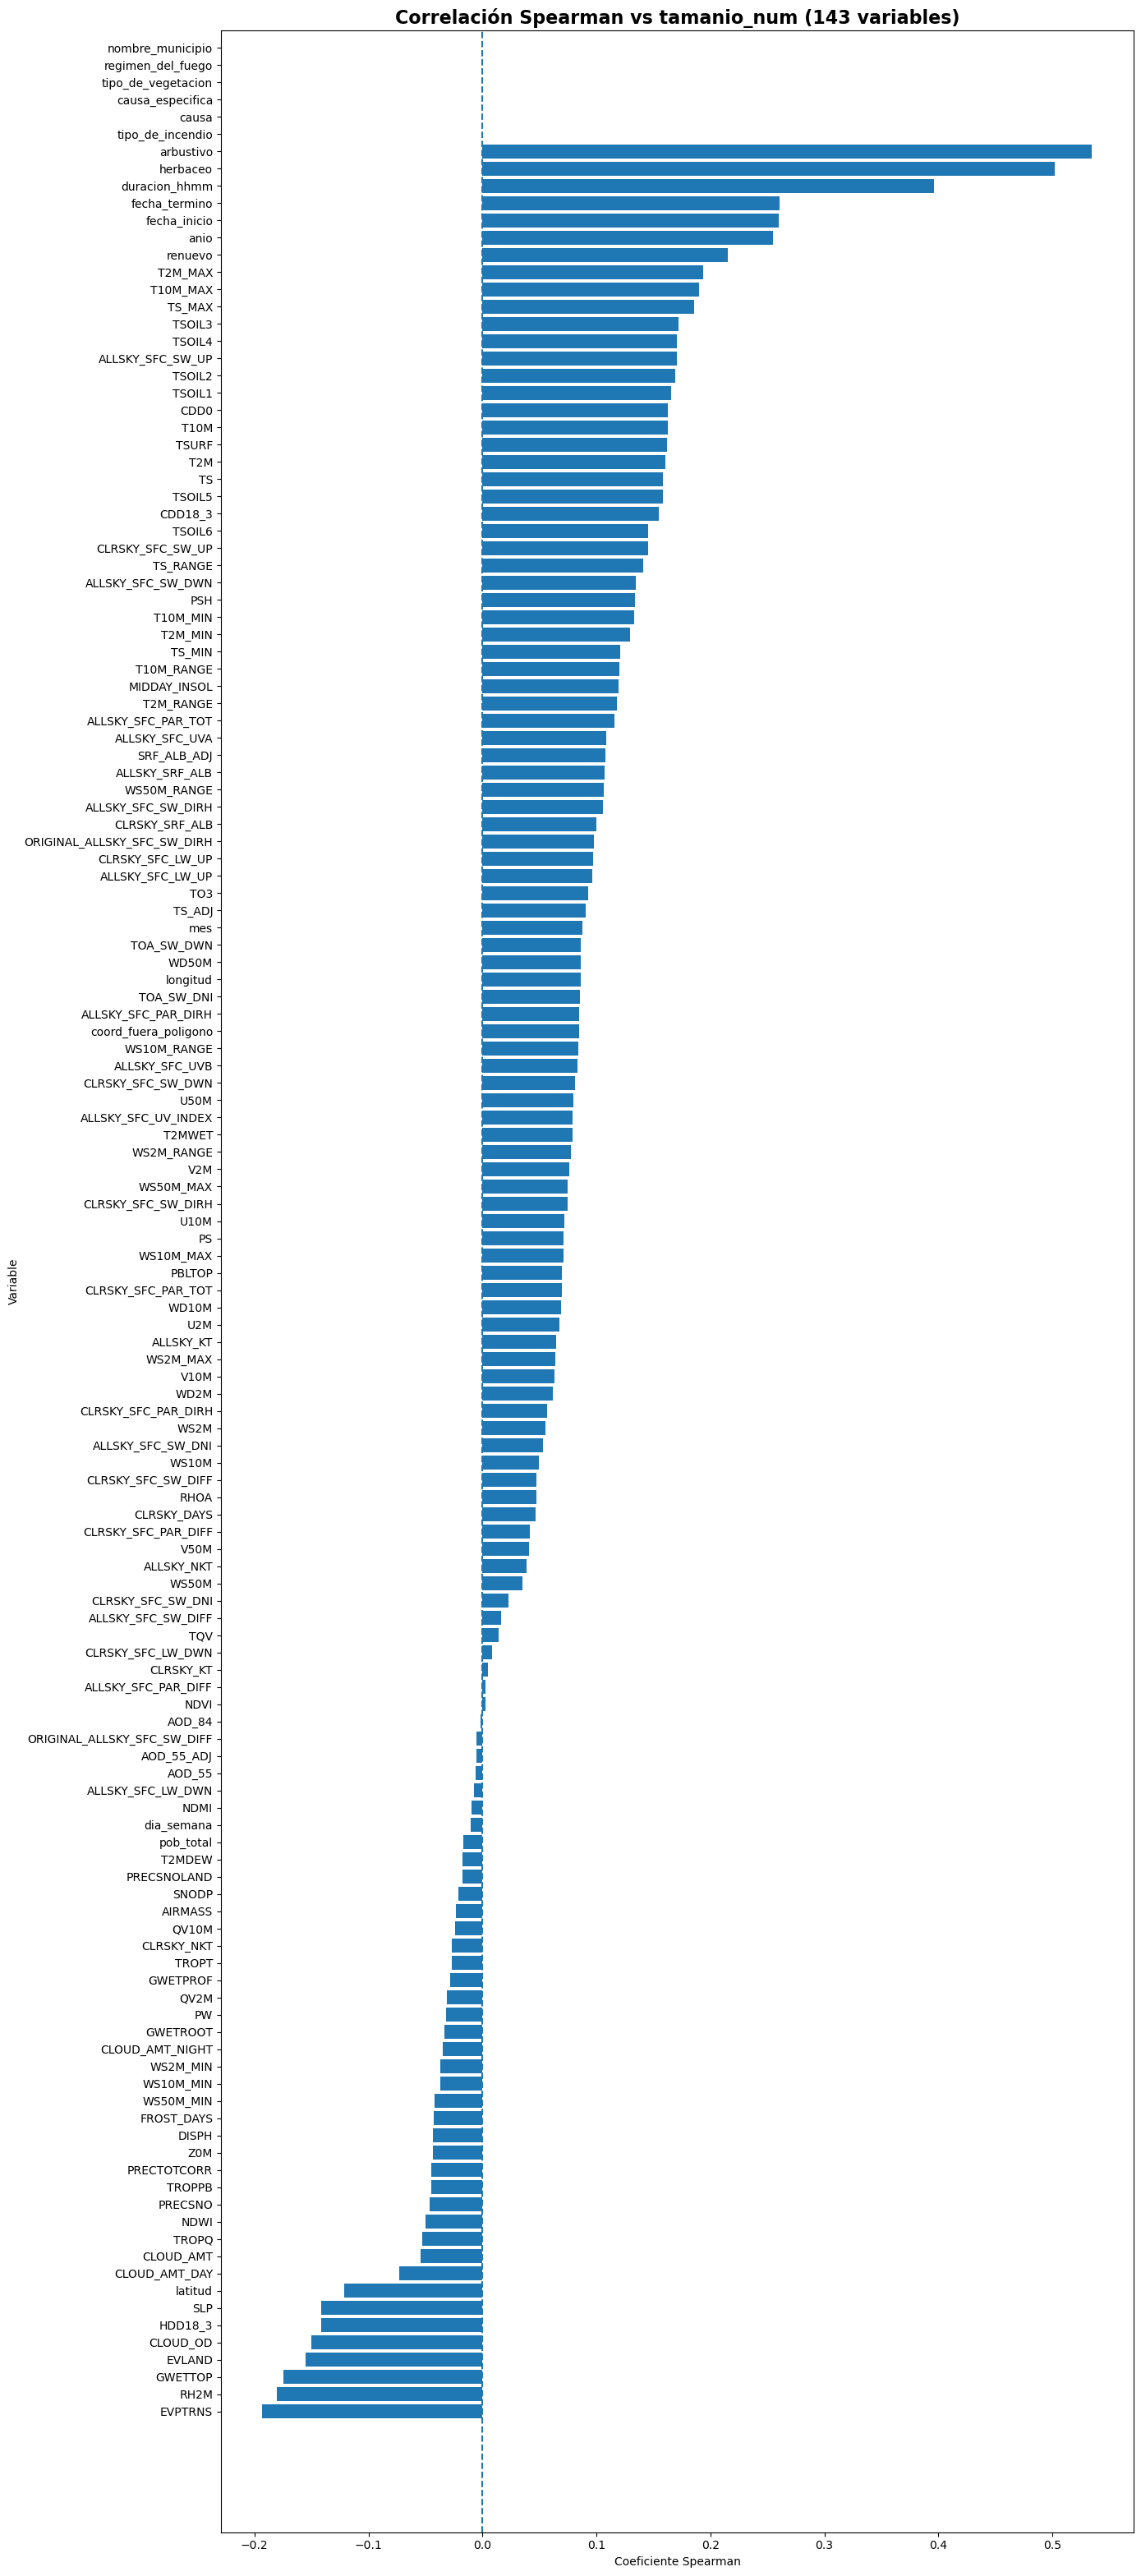


Gráfica guardada:
spearman_tamanio_completo.png



=== GENERANDO MAPA DE CALOR DE CORRELACIÓN ===


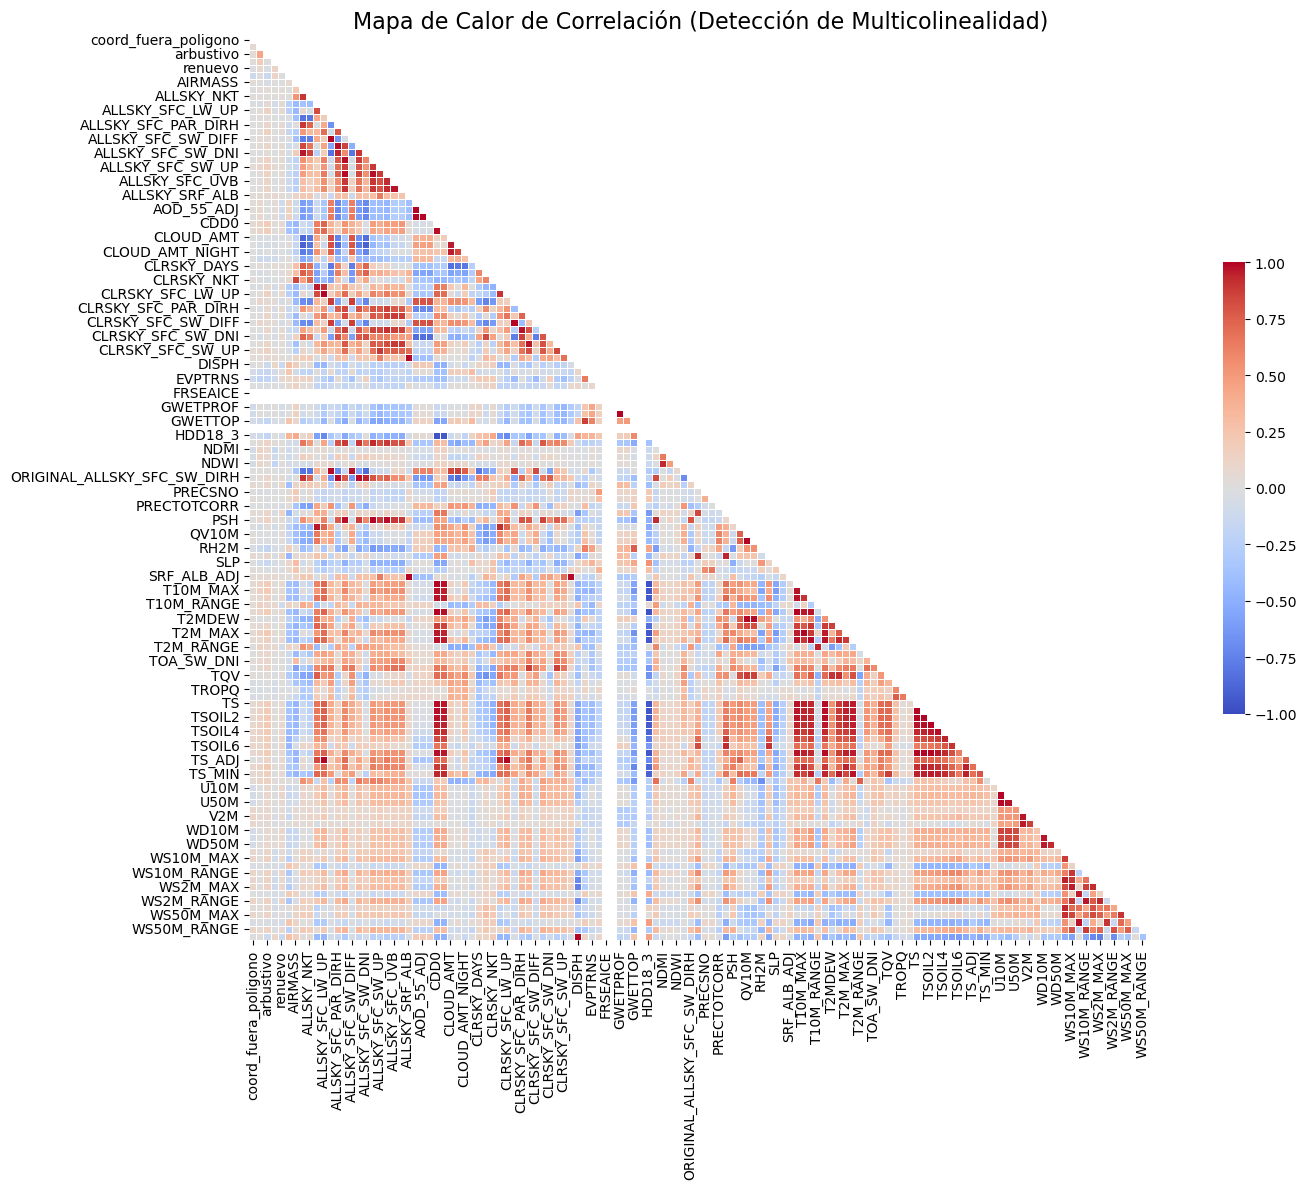

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n=== GENERANDO MAPA DE CALOR DE CORRELACIÓN ===")

# 1. Definimos qué columnas NO queremos en el análisis de correlación
# (No tiene sentido correlacionar un ID o un año con el clima)
cols_excluir = [
    'id_clave_inc', 'id_cvegeo', 'anio', 'mes', 'dia_semana', 
    'latitud', 'longitud'
]

# 2. Seleccionamos solo las variables numéricas del dataframe
cols_numericas = df_eda2.select_dtypes(include=[np.number]).columns.tolist()

# 3. Filtramos para quedarnos solo con las variables de análisis (clima, daños, pob_total)
cols_analisis = [col for col in cols_numericas if col not in cols_excluir]

# 4. Calculamos la matriz de correlación (Spearman es ideal para capturar relaciones no lineales)
corr_matrix = df_eda2[cols_analisis].corr(method='spearman')

# 5. Dibujamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(16, 12))

# Máscara para ver solo la mitad del triángulo y no duplicar visualmente la información
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', # Rojo = correlación positiva alta, Azul = correlación negativa alta
    vmin=-1, vmax=1, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}
)

plt.title('Mapa de Calor de Correlación (Detección de Multicolinealidad)', fontsize=16)
plt.tight_layout()

# Mostrar el gráfico en una ventana emergente en lugar de guardarlo
plt.show()

In [6]:
import pandas as pd
import numpy as np

# 1. Filtro inicial: Variables que no entran al análisis estadístico
cols_excluir = [
    'id_clave_inc', 'id_cvegeo', 'anio', 'mes', 'dia_semana', 
    'latitud', 'longitud', 'tamanio', 'fecha_inicio', 'fecha_termino', 
    'hora_deteccion', 'hora_llegada', 'duracion_hhmm'
]

cols_num = df_eda2.select_dtypes(include=[np.number]).columns.tolist()
cols_analisis = [c for c in cols_num if c not in cols_excluir]

# 2. Calcular matriz de correlación (Spearman)
# Spearman es mejor porque detecta si una sube cuando la otra sube, 
# aunque no sea una línea recta perfecta.
print("Analizando relaciones entre variables...")
corr_matrix = df_eda2[cols_analisis].corr(method='spearman').abs()

# 3. Agrupar variables "gemelas"
umbral = 0.85
visitadas = set()
grupos_redundantes = []

for i, var_a in enumerate(cols_analisis):
    if var_a in visitadas:
        continue
    
    # Encontrar todas las variables muy parecidas a var_a
    similares = corr_matrix.index[corr_matrix[var_a] >= umbral].tolist()
    
    if len(similares) > 1:
        grupos_redundantes.append(similares)
        visitadas.update(similares)

# 4. Mostrar el reporte de "Gemelas"
print(f"\n=== REPORTE DE VARIABLES REDUNDANTES (Umbral > {umbral}) ===")
print("Las siguientes variables están tan relacionadas que podrías dejar solo UNA por grupo:\n")

variables_a_conservar = []
variables_a_descartar = []

for i, grupo in enumerate(grupos_redundantes, 1):
    # Por defecto, sugerimos conservar la primera (o la que tenga menos nulos)
    # Aquí calculamos cuál tiene menos nulos en el DF original
    mejor_rep = df_eda2[grupo].isnull().sum().idxmin()
    otros = [v for v in grupo if v != mejor_rep]
    
    variables_a_conservar.append(mejor_rep)
    variables_a_descartar.extend(otros)
    
    print(f"Grupo {i}:")
    print(f"  ✅ SUGERIDA (Menos nulos): {mejor_rep}")
    print(f"  ❌ REDUNDANTES: {', '.join(otros)}")
    print("-" * 50)

# 5. Variables que no tienen gemelas (únicas)
unicas = [v for v in cols_analisis if v not in visitadas]
variables_finales = variables_a_conservar + unicas

print("\n=== RESUMEN ESTRATÉGICO ===")
print(f"Total variables analizadas : {len(cols_analisis)}")
print(f"Variables únicas (sin gemelas): {len(unicas)}")
print(f"Variables representativas de grupos: {len(variables_a_conservar)}")
print(f"Variables a descartar por redundancia: {len(variables_a_descartar)}")
print(f"\n🚀 TOTAL VARIABLES PARA TU MODELO: {len(variables_finales)}")

Analizando relaciones entre variables...

=== REPORTE DE VARIABLES REDUNDANTES (Umbral > 0.85) ===
Las siguientes variables están tan relacionadas que podrías dejar solo UNA por grupo:

Grupo 1:
  ✅ SUGERIDA (Menos nulos): AIRMASS
  ❌ REDUNDANTES: CLRSKY_NKT
--------------------------------------------------
Grupo 2:
  ✅ SUGERIDA (Menos nulos): ALLSKY_KT
  ❌ REDUNDANTES: ALLSKY_NKT, ALLSKY_SFC_PAR_DIRH, ALLSKY_SFC_SW_DNI, CLOUD_AMT, CLOUD_AMT_DAY, ORIGINAL_ALLSKY_SFC_SW_DIRH
--------------------------------------------------
Grupo 3:
  ✅ SUGERIDA (Menos nulos): ALLSKY_SFC_LW_DWN
  ❌ REDUNDANTES: CLRSKY_SFC_LW_DWN, PW
--------------------------------------------------
Grupo 4:
  ✅ SUGERIDA (Menos nulos): ALLSKY_SFC_LW_UP
  ❌ REDUNDANTES: CLRSKY_SFC_LW_DWN, CLRSKY_SFC_LW_UP, TS_ADJ
--------------------------------------------------
Grupo 5:
  ✅ SUGERIDA (Menos nulos): ALLSKY_SFC_PAR_DIFF
  ❌ REDUNDANTES: ALLSKY_SFC_SW_DIFF, CLRSKY_SFC_PAR_DIFF, CLRSKY_SFC_SW_DIFF, ORIGINAL_ALLSKY_SFC_SW_